## Advandex - оценка вероятности клика

**Цель:**
Построить модель бинарной классификации, которая предсказывает вероятность клика — показатель CTR — на рекламное объявление

**Задачи**
1. Сформулировать задачу: предсказание вероятности клика (CTR) как бинарную классификацию.

2. Провести EDA:
   - изучить распределения признаков,
   - выявить пропуски и аномалии,
   - оценить дисбаланс классов.

3. Разбить данные на выборки:
   - обучающая,
   - калибровочная,
   - финальный тест,
   с использованием стратификации.

4. Построить пайплайн предобработки:
   - обработка пропусков,
   - кодирование категориальных признаков (OHE, Target Encoding),
   - масштабирование числовых признаков,
   - отбор признаков по дисперсии,
   - дополнительные преобразования (логарифмирование и др.).

5. Выполнить отбор признаков:
   - использовать методы фильтрации,
   - применить RFECV.

6. Обучить базовую модель:
   - DummyClassifier для проверки адекватности.

7. Обучить основные модели:
   - Logistic Regression,
   - линейный SVC.

8. Подобрать гиперпараметры:
   - использовать GridSearchCV,
   - применять кросс-валидацию и метрику PR-AUC.

9. Оценить качество моделей:
   - сравнить с базовой моделью,
   - проанализировать метрики (PR-AUC, precision, recall, log loss и др.).

10. При необходимости откалибровать вероятности:
    - использовать калибровочную выборку,
    - применить методы (Platt scaling / isotonic).

11. Провести финальную оценку:
    - использовать отложенную тестовую выборку.

12. Сохранить итоговую модель:
    - сериализовать пайплайн и обученную модель.

## 1. Подготовка среды и загрузка данных

#### 1.1 Подготовьте библиотеки

In [1]:
# Установка зависимостей
!pip install -q scikit-learn numpy pandas seaborn phik joblib

In [2]:
# Импорт библиотек
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import phik
import joblib

In [3]:
# Глобальная настройка библиотек
mpl.rcParams['figure.constrained_layout.use'] = True

In [4]:
# Random state
RANDOM_STATE=1703

# Целевая переменная
TARGET_COL = 'click'

In [5]:
# Загрузка датасета с кешированием на диске
try:
    df = pd.read_csv('./9. ds_s16_ad_click_dataset.csv')
    print('Dataset found locally.')
except:
    print('Dataset not found locally.')
    df = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s16_ad_click_dataset.csv')
    df.to_csv('./9. ds_s16_ad_click_dataset.csv')

Dataset found locally.


In [6]:
# Первые 5 строк данных
df.head()

,Unnamed: 0,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,...,ml_feature_1,ml_feature_2,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_7,ml_feature_8,ml_feature_9,ml_feature_10
0,0,1.005263e+19,1,14102100,1005,1,d9750ee7,98572c79,f028772b,ecad2386,...,-0.996823,A,0.666588,0,0.817292,0.993275,Z,-0.619959,0.433666,0.274038
1,1,1.010597e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,...,-0.391309,C,5.146789,1,-0.883865,-0.825722,X,0.576526,-0.318558,-0.132851
2,2,1.012048e+19,0,14102100,1005,0,d9750ee7,98572c79,f028772b,ecad2386,...,-2.112732,D,7.169348,0,-0.859440,-0.338365,Y,-0.440047,-0.345412,0.340487
3,3,1.021995e+18,0,14102100,1005,0,85f751fd,c4e18dd6,50e219e0,39cfef32,...,0.332707,A,-0.290708,1,0.062795,0.062934,Y,0.551982,0.733382,-0.198542
4,4,1.023455e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,...,1.166623,A,6.319134,1,-0.675276,0.797144,X,0.640827,0.297955,-0.136909


In [7]:
# Размерность данных
print('Количество столбцов: ', len(df.columns))
print('Количество строк: ', len(df))

Количество столбцов:  35
Количество строк:  50000


In [8]:
# Информация о столбцах
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 35 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        50000 non-null  int64  
 1   id                50000 non-null  float64
 2   click             50000 non-null  int64  
 3   hour              50000 non-null  int64  
 4   C1                50000 non-null  int64  
 5   banner_pos        50000 non-null  int64  
 6   site_id           50000 non-null  str    
 7   site_domain       50000 non-null  str    
 8   site_category     50000 non-null  str    
 9   app_id            50000 non-null  str    
 10  app_domain        50000 non-null  str    
 11  app_category      50000 non-null  str    
 12  device_id         50000 non-null  str    
 13  device_ip         50000 non-null  str    
 14  device_model      50000 non-null  str    
 15  device_type       50000 non-null  int64  
 16  device_conn_type  50000 non-null  int64  
 17  C14 

**Промежуточный вывод**

Данные успешно загружены. Более подробно рассмотрим их в следующем пункте

## 2. Исследовательский анализ данных (EDA)

#### 2.1 Опишите базовую информацию о датасете      

In [9]:
# Размерность данных
print('Признаков: ', len(df.columns))
print('Объектов: ', len(df))

Признаков:  35
Объектов:  50000


In [10]:
# Информация о типах данных
print('Типы данных:')
df.dtypes.value_counts()

Типы данных:


int64      16
str        11
float64     8
Name: count, dtype: int64

##### Описание признаков

| название           | группа                                   | тип      | описание                                                                 | полезность |
|--------------------|------------------------------------------|----------|--------------------------------------------------------------------------|------------|
| Unnamed: 0         | Идентификаторы и временные метки         | int64    | служебный индекс строки                                                  | нет - уникальный индентификатор строки      |
| id                 | Идентификаторы и временные метки         | float64  | уникальный идентификатор показа                                          | нет - уникальный индентификатор показа        |
| hour               | Идентификаторы и временные метки         | int64    | время показа в формате YYMMDDHH                                          | да         |
| click              | Целевая переменная                      | int64    | факт клика (1/0)                                                         | -          |
| C1                 | Характеристики баннера и аукциона        | int64    | анонимизированный признак контекста                                      | да         |
| banner_pos         | Характеристики баннера и аукциона        | int64    | позиция баннера                                                          | да         |
| site_id            | Характеристики рекламной площадки        | str      | идентификатор сайта                                                      | да         |
| site_domain        | Характеристики рекламной площадки        | str      | домен сайта                                                              | вероятно   |
| site_category      | Характеристики рекламной площадки        | str      | категория сайта                                                          | да         |
| app_id             | Характеристики приложения                | str      | идентификатор приложения                                                 | да         |
| app_domain         | Характеристики приложения                | str      | домен приложения                                                         | вероятно   |
| app_category       | Характеристики приложения                | str      | категория приложения                                                     | да         |
| device_id          | Устройство и соединение                  | str      | идентификатор устройства                                                 | нет  - уникальный индентификатор пользователя |
| device_ip          | Устройство и соединение                  | str      | IP-адрес устройства                                                      | нет - уникальный индентификатор пользователя |
| device_model       | Устройство и соединение                  | str      | модель устройства                                                        | да         |
| device_type        | Устройство и соединение                  | int64    | тип устройства                                                           | да         |
| device_conn_type   | Устройство и соединение                  | int64    | тип соединения                                                           | да         |
| C14                | Характеристики баннера и аукциона        | int64    | анонимизированный признак                                                | да         |
| C15                | Характеристики баннера и аукциона        | int64    | анонимизированный признак                                                | да         |
| C16                | Характеристики баннера и аукциона        | int64    | анонимизированный признак                                                | да         |
| C17                | Характеристики баннера и аукциона        | int64    | анонимизированный признак                                                | да         |
| C18                | Характеристики баннера и аукциона        | int64    | анонимизированный признак                                                | да         |
| C19                | Характеристики баннера и аукциона        | int64    | анонимизированный признак                                                | да         |
| C20                | Характеристики баннера и аукциона        | int64    | анонимизированный признак                                                | да         |
| C21                | Характеристики баннера и аукциона        | int64    | анонимизированный признак                                                | да         |
| ml_feature_1       | ML признаки                              | float64  | числовой сгенерированный признак                                         | да         |
| ml_feature_2       | ML признаки                              | str      | категориальный сгенерированный признак                                   | да         |
| ml_feature_3       | ML признаки                              | float64  | числовой сгенерированный признак                                         | да         |
| ml_feature_4       | ML признаки                              | int64    | числовой сгенерированный признак                                         | да         |
| ml_feature_5       | ML признаки                              | float64  | числовой сгенерированный признак                                         | да         |
| ml_feature_6       | ML признаки                              | float64  | числовой сгенерированный признак                                         | да         |
| ml_feature_7       | ML признаки                              | str      | категориальный сгенерированный признак                                   | да         |
| ml_feature_8       | ML признаки                              | float64  | числовой сгенерированный признак                                         | да         |
| ml_feature_9       | ML признаки                              | float64  | числовой сгенерированный признак                                         | да         |
| ml_feature_10      | ML признаки                              | float64  | числовой сгенерированный признак                                         | да         |

**Промежуточный вывод**

Загружены данные 50 тысяч показов рекламы. Каждый показ описан примерно 30 потенциально полезными признаками

В данных нет явных пропусков. Но потребуется проверка на неявные пропуски и аномалии

Данные представлены стандартным набором типов: int, float и str. Для числовых данных можно попробовать уменьшить разрядность со стандартных 64 бит до меньшего размера

#### 2.2 Анализ целевой переменной
- Проанализируйте, как распределена целевая переменная.
- Определите, есть ли дисбаланс классов. Это важно для выбора метрик.
- Посчитайте долю рекламы, на которую кликнули, и долю рекламы, на которую не кликнули.

In [11]:
# Значения целевой переменной
df[TARGET_COL].value_counts()

click
0    41397
1     8603
Name: count, dtype: int64

In [12]:
# Доли значений целевой переменной
df[TARGET_COL].value_counts() / len(df)

click
0    0.82794
1    0.17206
Name: count, dtype: float64

**Промежуточный вывод**

Заметен сильный дисбаланс классов. Доля совершенных кликов только 0.17. Потребуется учесть это при разбиение данных на выборки и обучении моделей

#### 2.3 Анализ признаков
Таблица с описанием признаков была представлена ранее. Из нее следует что следующие признаки точно бесполезны для обучения модели:
- Unnamed: 0 - уникальный индентификатор показа
- id - уникальный индентификатор пользователя
- device_id - уникальный индентификатор пользователя
- device_ip - уникальный индентификатор пользователя

Они будут проигнорированы в процессе обучения модели. Также сразу в список игнорирования добавим таргетную переменную (`click`):

In [13]:
# Список признаков для игнорирования
cols_to_ignore = ['Unnamed: 0', 'id', 'device_id', 'device_ip', TARGET_COL]

Дополнительно выделим в списки числовые и категориальные признаки:

In [14]:
# Выделение числовых и категориальных признаков
num_cols = pd.Series([col for col in df.columns if pd.api.types.is_numeric_dtype(df[col]) and col not in cols_to_ignore])
cat_cols = pd.Series([col for col in df.columns if pd.api.types.is_string_dtype(df[col]) and not col in cols_to_ignore])

num_cols, cat_cols

(0                 hour
 1                   C1
 2           banner_pos
 3          device_type
 4     device_conn_type
 5                  C14
 6                  C15
 7                  C16
 8                  C17
 9                  C18
 10                 C19
 11                 C20
 12                 C21
 13        ml_feature_1
 14        ml_feature_3
 15        ml_feature_4
 16        ml_feature_5
 17        ml_feature_6
 18        ml_feature_8
 19        ml_feature_9
 20       ml_feature_10
 dtype: str,
 0          site_id
 1      site_domain
 2    site_category
 3           app_id
 4       app_domain
 5     app_category
 6     device_model
 7     ml_feature_2
 8     ml_feature_7
 dtype: str)

Приведём числовые признаки к более экономичным типам (downcast), чтобы снизить затраты по времени и памяти при обработке данных:

In [15]:
# Downcast числовых признаков
for col in df.columns:  
	if pd.api.types.is_integer_dtype(df[col]):  
		df[col] = pd.to_numeric(df[col], downcast='integer')  
	elif pd.api.types.is_float_dtype(df[col]):  
		df[col] = pd.to_numeric(df[col], downcast='float')

In [16]:
# Перепроверка типов данных после downcast
df.dtypes.value_counts()

str        11
int16       7
float32     7
int8        6
int32       3
float64     1
Name: count, dtype: int64

**Промежуточный вывод**

Выделены 4 признака, явно бесполезные для обучения модели, они будут проигнорированы в дальнейшей работе с данными. 

Для числовых признаков выполнен downcast типов для уменьшения объемов занимаемой памяти и ускорения обработки данных.

#### 2.4 Анализ пропущенных значений
При первичном анализе явные пропуски не были выявлены. Перепроверим это:

In [17]:
# Количество пропусков в данных
df.isna().sum().sum() 

np.int64(0)

Пропуски в данных переданных для обучения отсутствуют. Но это не значит, что пропусков не будет в будущих данных, с которыми будет работать модель.

- Категориальные признаки - заполнение строкой `missing` и игнорирование в кодировщике признаков. Заполнение лучше добавить для большей уверенности в корректной обработке пропуска в кодировщике
- Числовые признаки - заполнение медианой

Это позволит модели продолжить работу в случае возникновения пропуска в данных. Но если пропусков станет много, то модель потеряет в качестве. Такие случаи стоит отслеживать

Дополнительно проверим данные на наличие явных дубликатов:

In [18]:
# Проверка на явные дубликаты
print(f'Количество дубликатов: {df.duplicated().sum()}')


Количество дубликатов: 0


In [19]:
# Проверка на дубликаты по неигрорированным признакам
print(f'Количество дубликатов: {df.duplicated().sum()}')

Количество дубликатов: 0


**Промежуточный вывод

Явные пропуски отсутствуют в данных, но может потребоваться в будущем. Для базовой обработки пропусков достаточно функциональности класса SimpleImputer

Явные дубликаты в данных не обнаружены

#### 2.5 Анализ категориальных признаков

Для начала посмотрим на список категориальных признаков

In [20]:
# Список категориальных признаков
cat_cols

0          site_id
1      site_domain
2    site_category
3           app_id
4       app_domain
5     app_category
6     device_model
7     ml_feature_2
8     ml_feature_7
dtype: str

In [21]:
# Количество уникальных значений в каждом признаке
df[cat_cols].nunique().sort_values(ascending=False)

device_model     2521
site_id          1160
site_domain      1013
app_id            976
app_domain         67
app_category       22
site_category      18
ml_feature_2        5
ml_feature_7        3
dtype: int64

`One-Hot Encoder` подходит только для обработки двух признаков `ml_feature_2` и `ml_feature_7`. Для остальных признаков лучше применить `TargetEncoder` из-за большого количества уникальнхы значений

In [22]:
# Разбиение признаков на две группы
cat_cols_ohe = ['ml_feature_2', 'ml_feature_7']
cat_cols_te = [col for col in cat_cols if col not in cat_cols_ohe]
cat_cols_ohe, cat_cols_te

(['ml_feature_2', 'ml_feature_7'],
 ['site_id',
  'site_domain',
  'site_category',
  'app_id',
  'app_domain',
  'app_category',
  'device_model'])

Проанализируем распределение значений для категориальных признаков:

In [23]:
# Функция для построения графиков countplot и barplot по данным для категориальных признаков
def plot_categorical_distributions(df, target, top_n = 20):
    
    fig, axes = plt.subplots(
        len(df.columns),
        2,
        figsize=(14, len(df.columns) * 3)
    )

    # если одна колонка
    if len(df.columns) == 1:
        axes = [axes]

    data = df.copy()

    for i, col in enumerate(df.columns):
        data[col] = data[col].fillna('missing')
        top = data[col].value_counts().nlargest(top_n).index
        plot_data = data[data[col].isin(top)]

        # 1. Countplot (частоты)
        sns.countplot(
            data=plot_data,
            x=col,
            ax=axes[i][0]
        )
        axes[i][0].set_title(f'{col} — count')
        axes[i][0].tick_params(axis='x', rotation=30)

        # 2. Barplot (средний target)
        sns.barplot(
            x=plot_data[col],
            y=target,
            estimator=np.mean,
            errorbar=None,
            ax=axes[i][1]
        )
        axes[i][1].set_title(f'{col} — mean(target)')
        axes[i][1].tick_params(axis='x', rotation=30)

    plt.show()

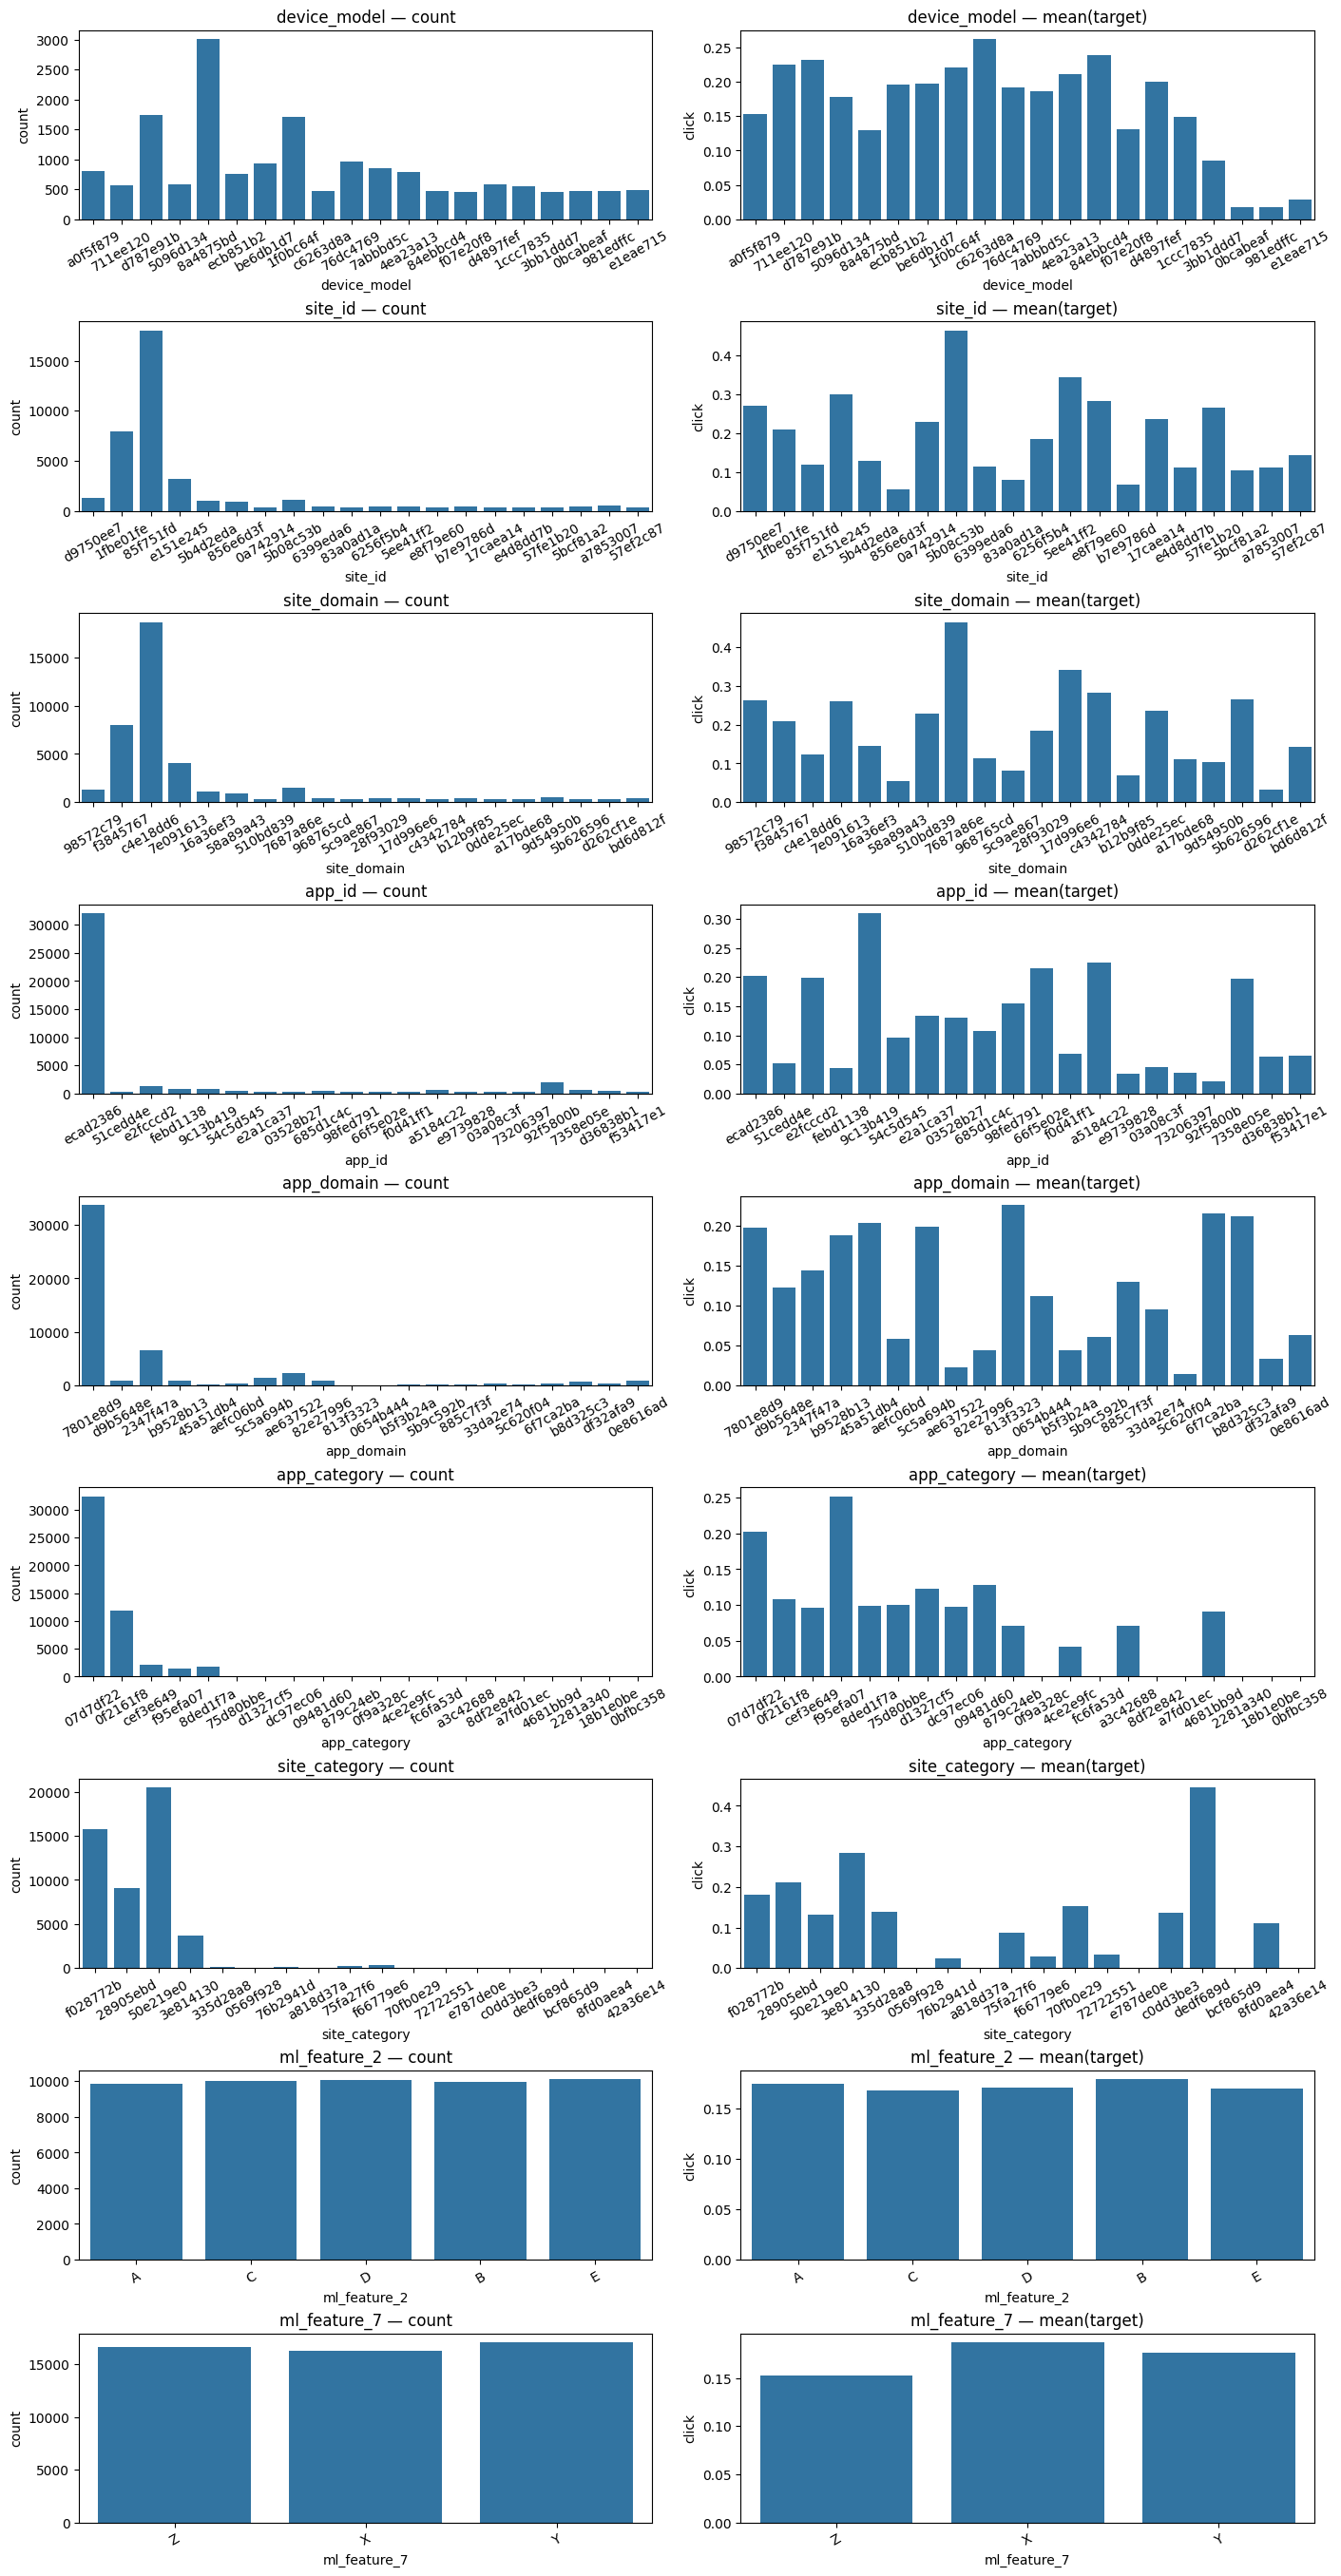

In [24]:
# Вывод графиков
plot_categorical_distributions(
    df[
        df[cat_cols].nunique().sort_values(ascending=False).index
    ],
    df[TARGET_COL]
)

Промежуточный вывод

Для обработки категориальных признаков потребуется применение `One-Hot Encoder` и `TargetEncoder`. Для обоих вариантов кодирования подготовлен список соответствующих признаков

Графики распределения значений показывают следующее:
- `ml_feature_2` и `ml_feature_7` - квазиконстантные. Скорее всего они будут отброшены в будущих этапах
- `site_id`, `site_domain`, `app_id`, `app_domain`, `app_cateogry` и `site_cateogry` - имеют несбалансированное распределение значений, небольшое число категорий доминирует. Скорее всего большинство этих признаков будут отброщены в дальнейшем анализе
- `device_model` - потенциально перспективный признак, но шум из-за большого количества уникальных значений может помешать обучению

#### 2.6 Анализ выбросов и распределений

Для удобства дальнейшей работы предварительно разделим признаки на булевы, дискретные и непрерывныe

In [25]:
# Вывод количества уникальных значений в каждом числовом признаке
df[num_cols].nunique().sort_values(ascending=False)

ml_feature_9        49990
ml_feature_5        49989
ml_feature_1        49980
ml_feature_10       49979
ml_feature_3        49978
ml_feature_8        49976
ml_feature_6        49927
C14                  1497
C17                   387
hour                  240
C20                   149
C19                    64
C21                    59
C16                     9
C15                     8
C1                      7
banner_pos              7
C18                     4
device_conn_type        4
device_type             4
ml_feature_4            2
dtype: int64

In [26]:
# Проверка признака на булевый тип
df['ml_feature_4'].value_counts()

ml_feature_4
0    25098
1    24902
Name: count, dtype: int64

В данных не найдено признаков булевого типа, поэтому разделим данные только на дискретные и непрерывныe:

In [27]:
DISCRETE_THRESHOLD = 20

discrete_cols = [
    col for col in num_cols
    if (
        pd.api.types.is_integer_dtype(df[col]) and
        df[col].nunique() <= DISCRETE_THRESHOLD
    )
]

continuous_cols = [
    col for col in num_cols
    if col not in discrete_cols
]

discrete_cols, continuous_cols

(['C1',
  'banner_pos',
  'device_type',
  'device_conn_type',
  'C15',
  'C16',
  'C18',
  'ml_feature_4'],
 ['hour',
  'C14',
  'C17',
  'C19',
  'C20',
  'C21',
  'ml_feature_1',
  'ml_feature_3',
  'ml_feature_5',
  'ml_feature_6',
  'ml_feature_8',
  'ml_feature_9',
  'ml_feature_10'])

Добавим функции для построения графиков. Для непрерывных числовых признаков построим histplot и boxplot. А для дискретных countplot

In [28]:
# Функция для построения графиков histplot + boxplot по данным для непрерывных числовых признаков
def plot_numeric_distributions(df):
    fig, axes = plt.subplots(len(df.columns), 2, figsize=(9, len(df.columns) * 2))

	# если одна колонка — axes не массив
    if len(df.columns) == 1:
        axes = [axes]

    for i, col in enumerate(df.columns):
        # HIST
        sns.histplot(data=df, x=col, ax=axes[i][0])
        axes[i][0].set_title(f'Распределение {col}')
        axes[i][0].set_xlabel(f'{col} (единицы)')
        axes[i][0].set_ylabel('Количество')

        # BOX
        sns.boxplot(data=df, x=col, ax=axes[i][1])
        axes[i][1].set_title(f'Boxplot {col}')
        axes[i][1].set_xlabel(f'{col} (единицы)')
        axes[i][1].set_ylabel('')

    plt.show()
    
# Функция для построения графиков countplot по данным для дискретных числовых признаков
def plot_categorical_distributions(df):
    fig, axes = plt.subplots(
        len(df.columns),
        1,
        figsize=(9, len(df.columns) * 2)
    )

    # если одна колонка — axes не массив
    if len(df.columns) == 1:
        axes = [axes]

    for i, col in enumerate(df.columns):
        sns.countplot(data=df, x=col, ax=axes[i])
        axes[i].set_title(f'Частоты категорий: {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Количество')
        axes[i].tick_params(axis='x', rotation=30)

    plt.show()

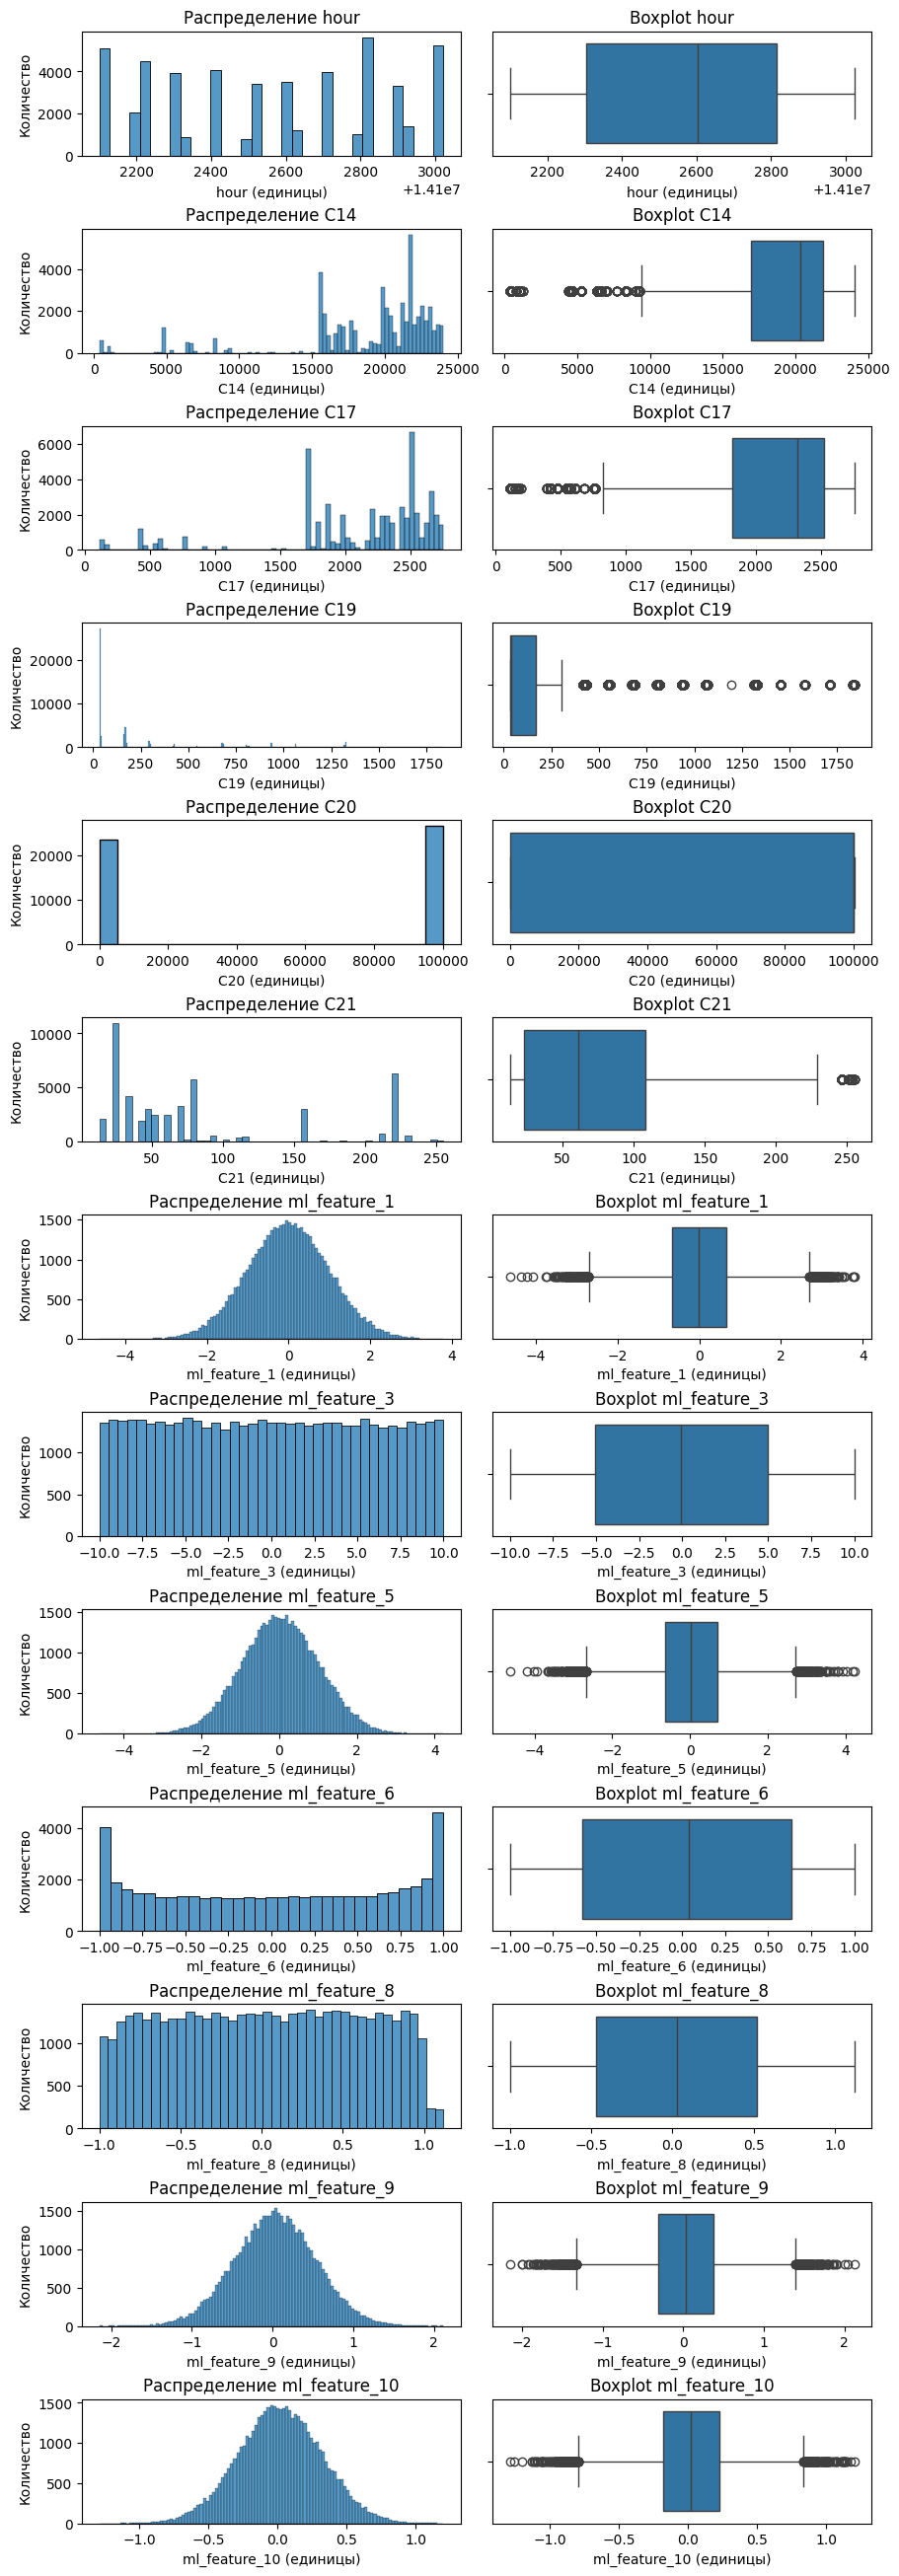

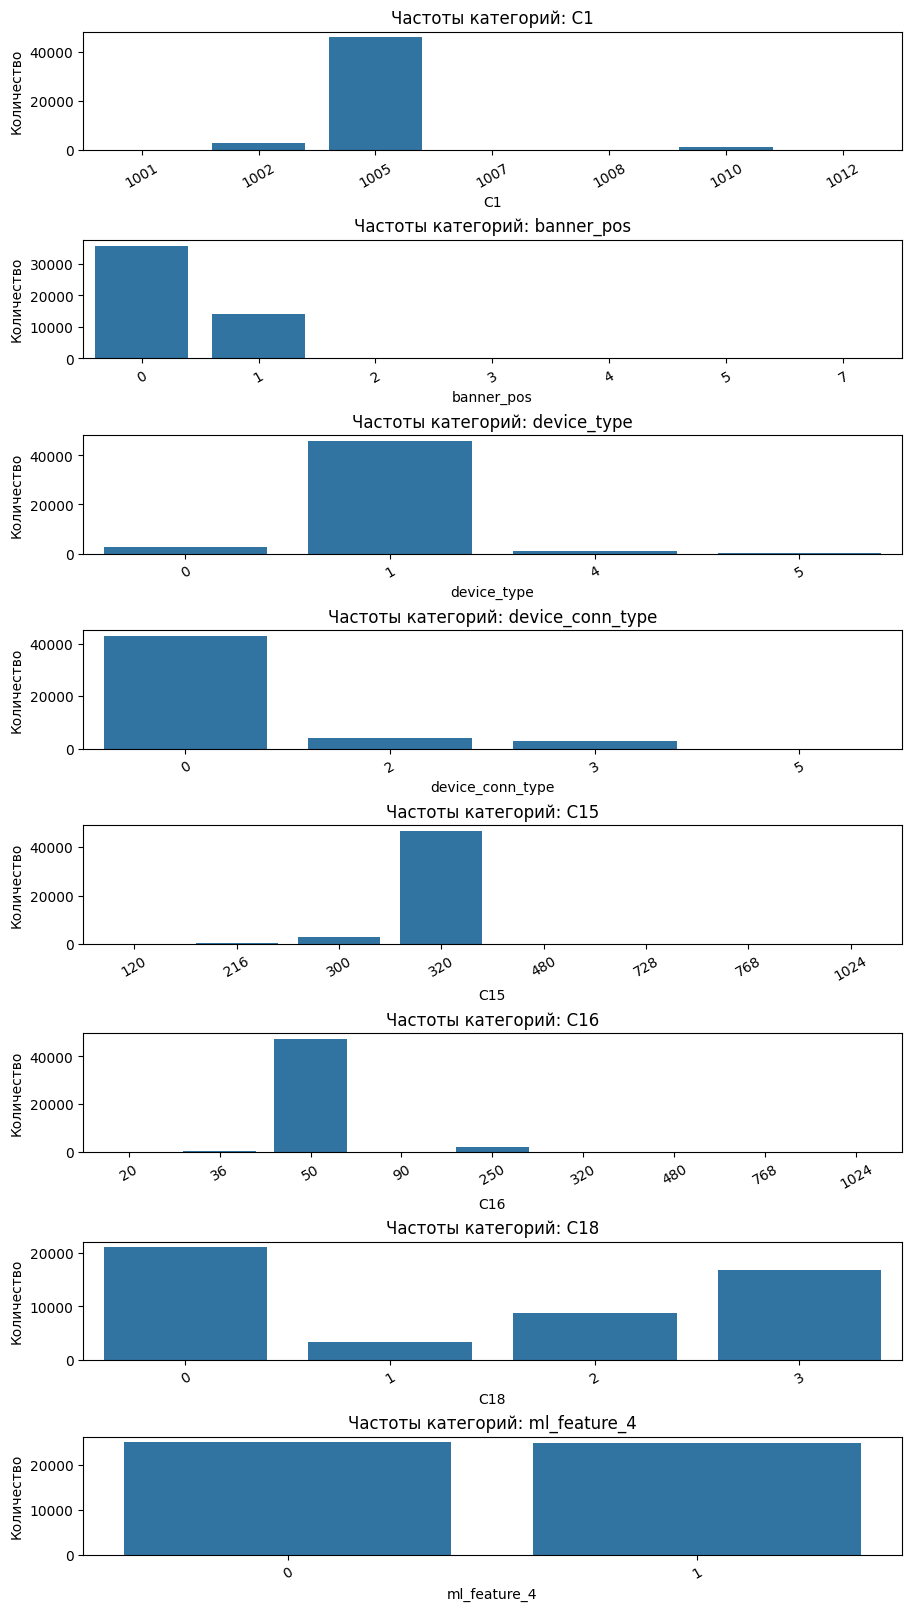

In [29]:
# Вывод графиков
plot_numeric_distributions(df[continuous_cols])
plot_categorical_distributions(df[discrete_cols])


- явные выбросы есть:
  - C14, C17, C19, C21 — много точек за пределами усов boxplot  
  - ml_feature_1, ml_feature_5, ml_feature_9, ml_feature_10 — выбросы с обеих сторон  
  - hour — почти без выбросов  
  - C20 — выбросов нет (бимодальное/дискретное)  

- характер распределения выбросов:
  - сильная асимметрия (правый хвост):
    - C19, C14, C17, C21 — длинный хвост вправо, редкие большие значения  
  - симметричные выбросы:
    - ml_feature_1, ml_feature_5, ml_feature_9, ml_feature_10 — нормальное распределение + хвосты  
  - равномерное / без выраженных выбросов:
    - ml_feature_3, ml_feature_6, ml_feature_8  
  - дискретное / кластерное:
    - C20 — значения сконцентрированы в нескольких точках  

- выводы по дискретным признакам:
  - категориальные признаки имеют сильный дисбаланс частот (несколько доминирующих категорий)
  - много редких категорий с очень низкой частотой (длинный хвост)
  - распределения неравномерные, часто с перекосом в сторону топ-значений
  - встречаются признаки с почти бинарным или квази-бинарным распределением
  - возможна высокая кардинальность (особенно id-подобные признаки)


Дополнительная обработка
- Значения в признаках с асимметричными распределением дополнительно логарифмируем в пайплайне. 
- Для признака C20 целесообразно преобразовать его в бинарный: установить значение 1, если исходное значение больше медианы, иначе 0

In [30]:
# Сохранение признаков, которым далее потребуется отдельная обработка
cols_to_log = ['C19', 'C14', 'C17', 'C21']
cols_to_bin = ['C20']

In [31]:
# Проверка на минимальные значения признаков. Должны быть >= 0 для успешного логарифмирования
(df[cols_to_log].min() > 0).all()

np.True_

**Промежуточный вывод**
  - выбросы в основном асимметричные (правосторонние) в категориально-кодированных признаках  
  - в синтетических (ml_feature_*) — близки к нормальным, выбросы естественные  
  - категориальные признаки имеют выраженный дисбаланс и длинный хвост редких значений

#### 2.7 Корреляции

Оценим корреляцию двумя способами:

1. Для категориальных признаков с большим количеством уникальных значений (`device_model`, `site_id`, `site_domain`, `app_id`) посчитаем Mutual Information
2. Для остальных признаков посчтиаем коэффициент phik

In [32]:
# Функция для построения тепловой карты
def heatmap(df):
    plt.figure(figsize=(20, 15))

    sns.heatmap(
        df,
        cmap="coolwarm",
        vmin=0, vmax=1,
        annot=True, fmt=".2f",
        linewidths=0.5,
        square=True,
        cbar_kws={"shrink": 0.8}
    )

    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)

    plt.title("Phik Correlation Matrix", fontsize=16)
    plt.show()

In [33]:
# Разбиение признаков на две группы для анализа
cols_to_mi = ['device_model', 'site_id', 'site_domain', 'app_id']
cols_to_phik = [
    col for col in df.columns 
    if col not in cols_to_ignore and
    col not in cols_to_mi   
] + [TARGET_COL]

In [34]:
# Mutual Information для отдельных признаков
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(df[cols_to_mi], df[TARGET_COL], discrete_features=True)
pd.Series(mi, index=cols_to_mi).sort_values(ascending=False)


site_id         0.045022
device_model    0.042778
site_domain     0.040508
app_id          0.029739
dtype: float64

У данных признаков низкий показатель MI, но и не достаточно близкий к нулю, чтобы признаки явно подходили под удаление. Оставим их до дальнейшего отбора признаков

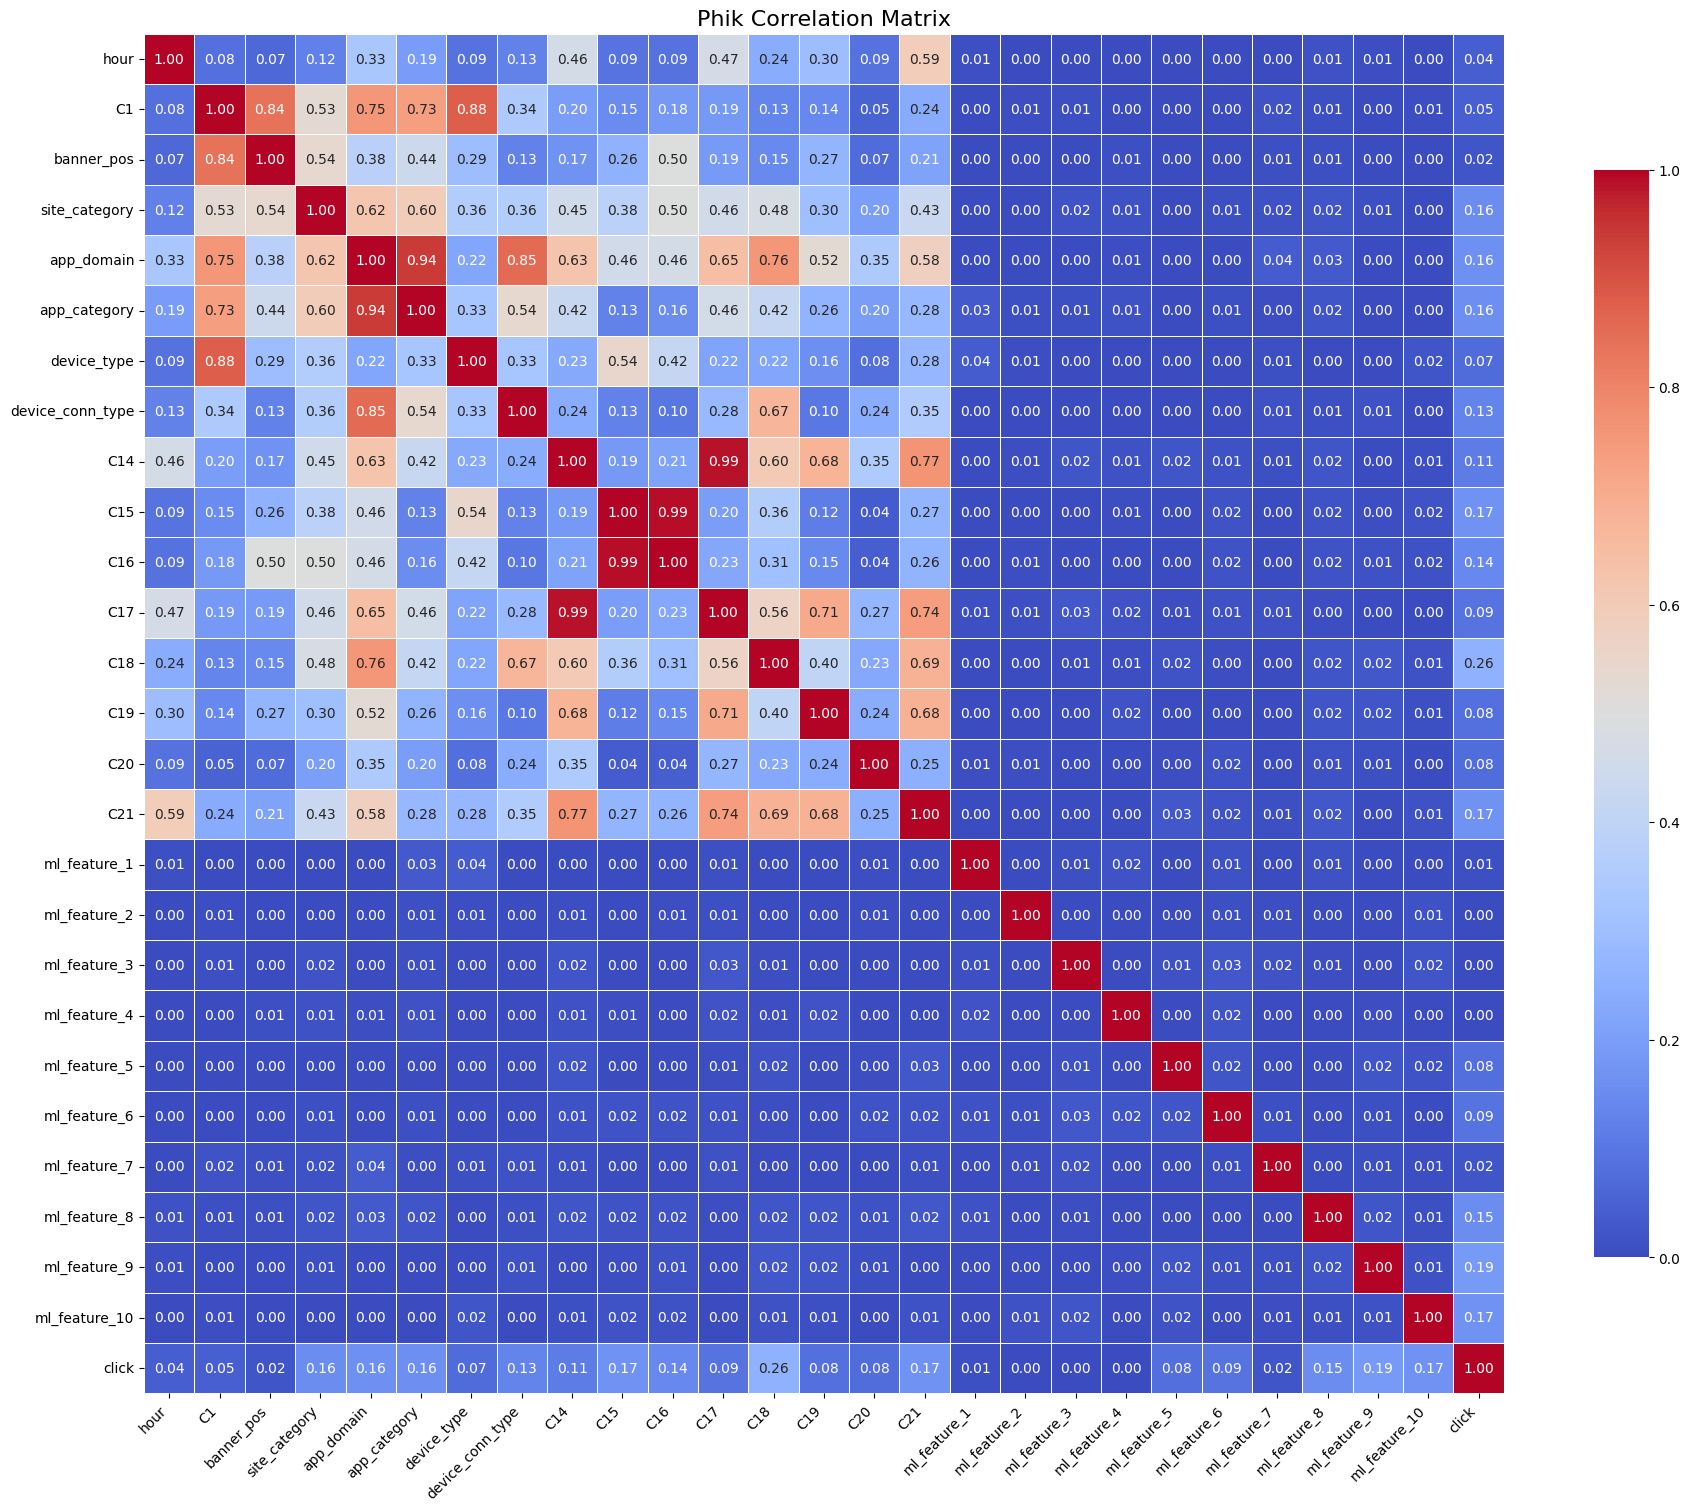

In [35]:
# Построение тепловой карты
df_phik = df[cols_to_phik].phik_matrix(interval_cols=continuous_cols)
heatmap(df_phik)

Тепловая карта дает очень шумный результат, так как все не машинно-сгенерированные признаки показывают корреляцию между собой. Посмотрим на результат phik в виде отсортированного по силе корреляции списка пар:

In [36]:
# Функция для получения списка пар признаков с корреляцией из phik матрицы
def phik_to_pairs(df_phik):
    s = df_phik.stack()
    s = s[s.index.get_level_values(0) != s.index.get_level_values(1)]
    s = s[s.index.get_level_values(0) < s.index.get_level_values(1)]
    s = s.sort_values(ascending=False)
    return s

In [37]:
# Наиболее сильные корреляции
phik_to_pairs(df_phik).head(20)

C15           C16                 0.991856
C14           C17                 0.986664
app_category  app_domain          0.940104
C1            device_type         0.875786
app_domain    device_conn_type    0.854520
C1            banner_pos          0.836595
C14           C21                 0.765524
C18           app_domain          0.755324
C1            app_domain          0.754581
C17           C21                 0.738735
C1            app_category        0.734659
C17           C19                 0.708376
C18           C21                 0.685700
C19           C21                 0.683898
C14           C19                 0.676999
C18           device_conn_type    0.673046
C17           app_domain          0.647653
C14           app_domain          0.626053
app_domain    site_category       0.619541
C14           C18                 0.602385
dtype: float64

In [38]:
# Корреляции с целевой переменной
df_phik[[TARGET_COL]].drop(index=TARGET_COL).sort_values(by=TARGET_COL, ascending=False)

,click
C18,0.257840
ml_feature_9,0.187801
ml_feature_10,0.169983
C21,0.166235
C15,0.165941
app_domain,0.161289
app_category,0.156537
site_category,0.155008
ml_feature_8,0.153598
C16,0.144262


Удалим несколько признаков из дальнейшей обработки по следующим критериям:
1. У признака кореляция с таргетов меньше 0.01 
2. У двух признаков кореляция между собой выше 0.8, тогда удаляется признак с меньшей корреляцией с таргетом 

Под критери попадают следующие признаки:

In [39]:
# Признаки неподходящие под критерии
cols_to_ignore_by_phik = [
    'ml_feature_2', # Низкая коррляция с таргетом
    'ml_feature_3', # Низкая коррляция с таргетом
    'ml_feature_4', # Низкая коррляция с таргетом
    'C16', # Высокая корреляция с C17,
    'C17', # Высокая корреляция с C14
    'app_category', # Высокая корреляция с app_domain
    'C1', # Высокая корреляция с device_type и banner_pos
    'device_conn_type', # Высокая корреляция с app_domain
]

cols_to_ignore += cols_to_ignore_by_phik

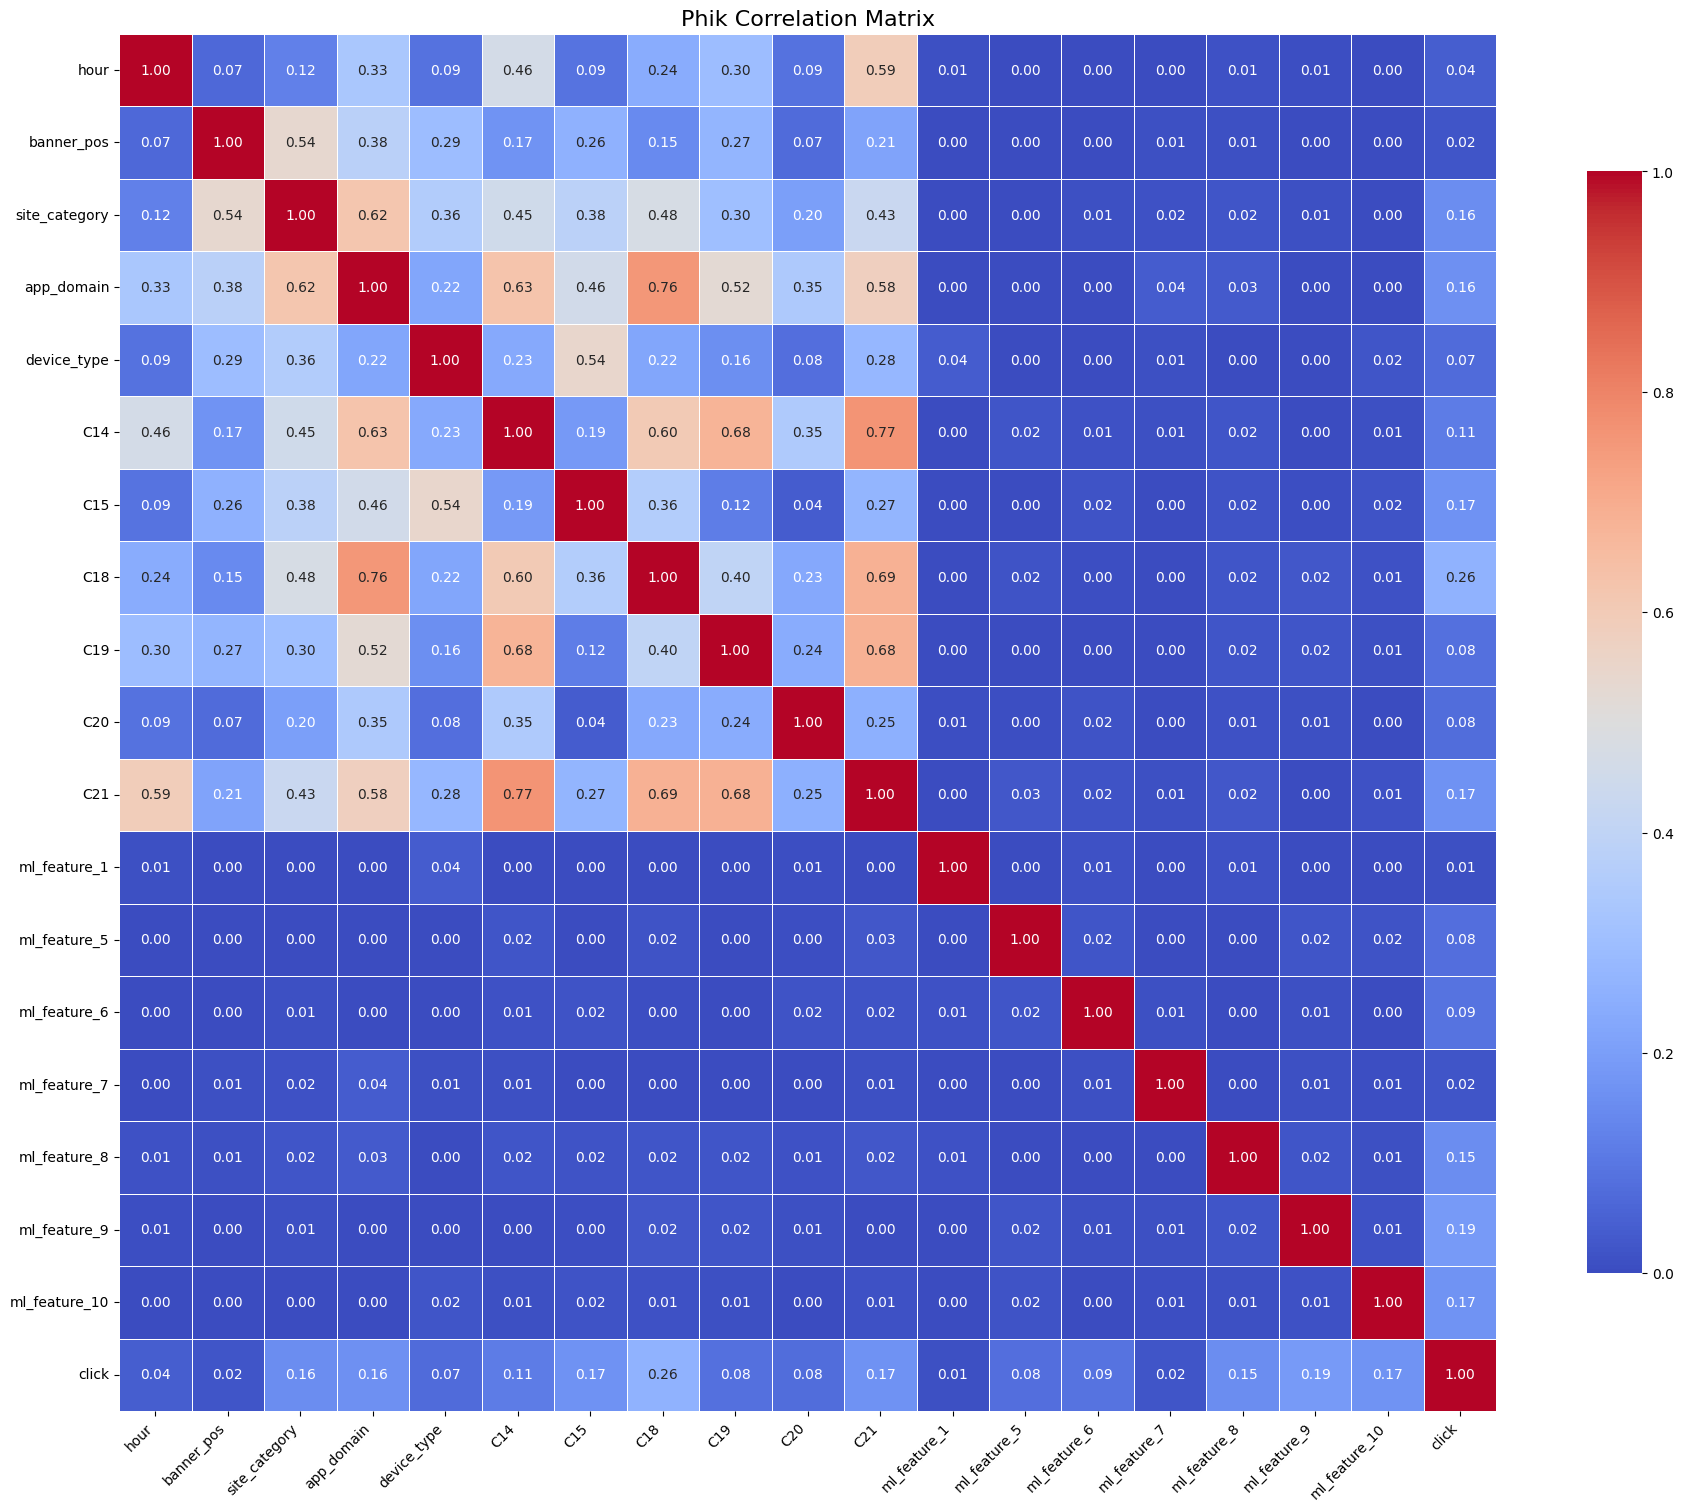

In [40]:
# Посмотрим на phik корреляцию еще раз
cols_to_phik = [
    col for col in df.columns 
    if col not in cols_to_ignore and
    col not in cols_to_mi   
] + [TARGET_COL]

df_phik = df[cols_to_phik].phik_matrix(interval_cols=continuous_cols)
heatmap(df_phik)

Phik корреляия между признаками стала меньше, при этом остались признаки коррелирующие с таргетом. 

Можно было бы продолжить удаление признаков на этом этапе и по меньшему порогу phik, но для этого требуется информация об анонимных признаках. Так что дальнейшее уменьшение количества малоинформативных признаков оставим на будушие этапы

**Промежуточный вывод**

Признаки проверены на корреляцию между и собой и корреляцию с таргетом с помощью phik и mi. По итогу проверки несколько признаков были удалены из выборкипеременной (таргетом) с использованием методов phik и mutual information (mi). 
Те признаки, которые показали очень низкую корреляцию с таргетом (например, phik value < 0.01), были исключены как малоинформативные. 
Также из пар сильно коррелирующих между собой признаков (phik > 0.8) оставлялся только тот, у которого корреляция с таргетом выше; остальные из этой группы также были удалены для уменьшения мультиколлинеарности в данных.
В результате этого этапа некоторые признаки были исключены из дальнейшего анализа, что позволит повысить качество последующих моделей и упростить интерпретацию результатов.

#### 2.8 Выводы по EDA
**Ключевые находки**

- Выборка: 50 тыс. показов, без явных пропусков и без полных дубликатов строк; типы уже приведены к более компактным (`downcast`) для экономии памяти.
- Целевая переменная бинарная; классы сильно несбалансированы: доля кликов порядка 17–18%. Для метрик и разбиения на train/test/validation это важно (нельзя ограничиваться только точностью; уместны AUC–PR, F1 при выбранном пороге, стратификация).
- Есть технические столбцы, не несущие обобщающей информации для модели: индекс строки, `id`, `device_id`, `device_ip` — они исключаются как идентификаторы.
- По распределениям: у части числовых признаков наблюдаются асимметрия и длинные правые хвосты (`C14`, `C17`, `C19`, `C21` и др.), у `ml_feature_*` картина ближе к нормальности с типичными «хвостами» boxplot; `hour` почти без выбросов.
- Категориальные признаки с неравномерными частотами: доминируют немного топ-значений, много редких категорий; возможна высокая кардинальность у некоторых полей контекста площадки/приложения.
- Анализ связей через phik и взаимную информацию: часть малокоррелирующих с таргетом признаков отбрасывается; из сильных пар (phik > 0.8) сохранён признак с большей связью с `click`, чтобы снизить мультиколлинеарность.

**Наиболее перспективные признаки (и почему)**

- **Контекст площадки и приложения** (`site_*`, `app_*`): отражают среду показа; по EDA они дают сильный разброс частот категорий и обычно несут сигнал CTR.
- **Устройство** (`device_model`, `device_type`, `device_conn_type`): различие по типу устройства и соединения типично влияет на клики.
- **Параметры баннера и аукциона** (`banner_pos`, `C1`, `C14`–`C21`): связаны с форматом и позицией показа и с анонимизированными аукционными признаками; по распределениям и корреляциям они включаются в модель после отбора.
- **Числовые `ml_feature_1`, … `ml_feature_10`**: уже агрегированы/спроектированы под задачу, по графикам ведут себя как информативные непрерывные и смешанные признаки.
- **Время** (`hour`): дискретный маркер момента показа, без доминирования выбросов; имеет смысл как сезонность в пределах суток и дней.

Признаки после фильтра по phik/MI считаются наиболее обоснованным подмножеством для линейных моделей по балансу сигнал/шум и устранению избыточных дубликатов по информации.

**Предобработка перед обучением**

- Исключить из признаков: `Unnamed: 0`, `id`, `device_id`, `device_ip`; целевую `click` не подавать в X.
- Сохранить стратификацию при разбиении из-за дисбаланса классов; при необходимости — классовые веса или порог при оптимизации бизнес-метрики.
- Категории: кодирование по выбранной схеме (`OneHotEncoder` / `TargetEncoder` и т. п.); для редких категорий — ограничение кардинальности или объединение в «прочее»; на прод для пропусков в категориях можно зарезервировать уровень (например, `missing`), даже если в текущем датасете пропусков нет.
- Числа: для линейных моделей и дистанционных метрик — масштабирование при необходимости; долгосрочно — простая импутация для чисел (например, медиана) как защита на новых данных.
- Контроль мультиколлинеарности: опираться на уже проведённый отбор пар с высоким phik; при необходимости повторить проверку на train-части после кодирования.
- Выбросы: не удалять автоматически без гипотезы; для логистической регрессии возможны робастные преобразования или обрезка хвостов после анализа на обучающей выборке.

## 3. Разделение данных на выборки
#### 3.1 Разделите данные

In [116]:
# Разделение данных
from sklearn.model_selection import train_test_split

X = df.drop(columns=TARGET_COL)
y = df[TARGET_COL]

# основной сплит
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

# делим тест на calibration + test
X_calib, X_test, y_calib, y_test = train_test_split(
    X_test,
    y_test,
    test_size=0.5,
    random_state=RANDOM_STATE,
    stratify=y_test,
)

**Промежуточный вывод**

Данные разделены на тренировочную и тестовую выборки с применениям стратифицированного разделения для сохранения баланса классов

#### 3.2 Проверьте разделение

In [ ]:
# Размеры выборок
X_train.shape, X_calib.shape, X_test.shape, y_train.shape, y_calib.shape, y_test.shape

((40000, 34), (10000, 34), (40000,), (10000,))

In [43]:
# Распределение целевой переменной
y_train.value_counts(normalize=True), y_test.value_counts(normalize=True)

(click
 0    0.82795
 1    0.17205
 Name: proportion, dtype: float64,
 click
 0    0.8279
 1    0.1721
 Name: proportion, dtype: float64)

**Промежуточный вывод**

Данные разделены корректно в требуемой пропорции и с сохранением баланса классов в таргетной переменной

## 4. Предобработка данных — построение пайплайнов

In [44]:
# Класс для кастомного преобразования числовых признаков в бинарный (для C20)
# Класс вместо функции нужен для избезания утечки. Медиана в классе будет считаться только на тренировочных данных

from sklearn.base import BaseEstimator, TransformerMixin

class MedianBinarizer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.median_ = np.median(X)
        return self
    
    def transform(self, X):
        return (X > self.median_).astype(int)

    def get_feature_names_out(self, input_features=None):
        return np.asarray(input_features)

In [45]:
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, TargetEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import VarianceThreshold


# Пайплайн предобработки данных:
# - обрабатывает пропуски
# - обрабатывает выбросы через логарифмирование части числовых признаков
# - кодирует категориальные признаки
# - масштабирует числовые признаки
def get_preprocessor(num_cols, cols_to_log, cols_to_bin, ohe_cols, te_cols, cols_to_ignore):
    # Игнорирование части признаков, переданных в функцию
    num_cols = [col for col in num_cols if col not in cols_to_ignore]
    cols_to_log = [col for col in cols_to_log if col not in cols_to_ignore]
    cols_to_bin = [col for col in cols_to_bin if col not in cols_to_ignore]

    te_cols = [col for col in te_cols if col not in cols_to_ignore]
    ohe_cols = [col for col in ohe_cols if col not in cols_to_ignore]

    return Pipeline([
        ('preprocessor', ColumnTransformer([
            # Пайплайн для категориальных признаков с небольшим числом уникальных значений
            ('ohe', Pipeline([
                ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
                ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
            ]), ohe_cols),

            # Пайплайн для категориальных признаков с большим числом уникальных значений
            ('te', Pipeline([
                ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
                ('encoder', TargetEncoder(random_state=RANDOM_STATE))
            ]), te_cols),

            # Пайплайн для числовых признаков с выбросами:
            # заполняем пропуски, логарифмируем и масштабируем
            ('num_log', Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('log', FunctionTransformer(np.log1p, validate=False, feature_names_out='one-to-one')),
                ('scaler', StandardScaler())
            ]), cols_to_log),

            # Пайплайн для остальных числовых признаков:
            # заполняем пропуски и масштабируем
            ('num', Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())
            ]), [col for col in num_cols if col not in cols_to_log and col not in cols_to_bin]),

            # Пайплайн для кастомного преобразования числовых признаков в бинарный (для C20)
            ('bool_custom', Pipeline([
                ('transform', MedianBinarizer())
            ]), cols_to_bin),

        ], remainder='drop')),
        ('variance_threshold', VarianceThreshold(threshold=0.01))
    ])
    

## 5. Отбор признаков

#### 5.1 Примените фильтрационные методы
- Посчитайте корреляцию каждого признака с целевой переменной.
- Отберите топ лучших признаков. Объясните, почему остановились именно на таком количестве признаков.
- Удалите признаки с очень низкой вариацией `VarianceThreshold`.

Фильтрация на основе корреляции уже была применена в пункте 2.7. 

`VarianceThreshold` для фильтрации уже интегрирован в пайплайн подготовки данных. Из него мы можем получить информацию о том, какие признаки будут проигнорированны из-за низкой дисперсии:

In [46]:
# Получение признаков, которые будут проигнорированы из-за низкой дисперсии из пайплайна
preprocessor = get_preprocessor(
    num_cols, 
    cols_to_log, 
    cols_to_bin, 
    cat_cols_ohe, 
    cat_cols_te, 
    cols_to_ignore
)

preprocessor.fit(X_train, y_train)

print('Признаки, которые будут проигнорированы из-за низкой дисперсии:')

low_variance_features = preprocessor.named_steps['preprocessor'].get_feature_names_out()[
    preprocessor.named_steps['variance_threshold'].get_support() == False
]
low_variance_features = [c.replace('te__', '') for c in low_variance_features]
low_variance_features

Признаки, которые будут проигнорированы из-за низкой дисперсии:


['site_category', 'app_id', 'app_domain']

Это соответствует выводу в пункте 2.5 - где эти признаки были отмечены как потенциально малоинформативные

In [47]:
# Добавим признаки с низкой дисперсией в список признаков для удаления
cols_to_ignore += low_variance_features
sorted(cols_to_ignore)

['C1',
 'C16',
 'C17',
 'Unnamed: 0',
 'app_category',
 'app_domain',
 'app_id',
 'click',
 'device_conn_type',
 'device_id',
 'device_ip',
 'id',
 'ml_feature_2',
 'ml_feature_3',
 'ml_feature_4',
 'site_category']

**Промежуточный вывод**
Из-за низкой дисперсии дополнительно удалены три признака: `site_category`, `app_id`, `app_domain`

#### 5.2 Примените методы-обёртки

В качестве метода отбора признаков используем RFECV (Recursive Feature Elimination with Cross-Validation) — wrapper-подход, при котором признаки отбираются на основе качества работы модели. Алгоритм итеративно обучает модель, удаляет наименее важные признаки и на каждом шаге оценивает результат с помощью кросс-валидации. Это позволяет автоматически определить оптимальное количество признаков и оставить только те, которые действительно улучшают качество модели по выбранной метрике.

В идеале отбор признаков в рамках RFECV следует выполнять отдельно для каждой модели, так как набор информативных признаков зависит от её природы и способа обучения. Однако такой подход значительно увеличивает время расчётов. Поэтому в данном проекте для упрощения и ускорения процесса отбор будет выполнен один раз с использованием логистической регрессии — быстрой и устойчивой модели, способной корректно оценивать важность признаков. Полученный набор признаков затем будет использован для обучения всех моделей далее.

In [48]:
# Создание стандартного разбиения StratifiedKFold для проекта
from sklearn.model_selection import StratifiedKFold
cv_default = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [179]:

# Подготовка компонентов
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFECV

# препроцессор
preprocessor = get_preprocessor(
    num_cols, 
    cols_to_log, 
    cols_to_bin, 
    cat_cols_ohe, 
    cat_cols_te, 
    cols_to_ignore
)

# модель
model = LogisticRegression(
        # penalty='l1', # for old sklearn verions < 1.8
        l1_ratio=1, # for new sklearn verions >= 1.8
        solver='saga',
        random_state=RANDOM_STATE, 
        class_weight='balanced',
        max_iter=1000
    )

# метод-обертка
selector = RFECV(
    estimator=model,
    step=1,
    cv=cv_default,
    min_features_to_select=5,
    n_jobs=-1,
    scoring='average_precision',
)

# Пайплайн для отбора признаков

# ! TargetEncoder обучается до RFECV и возможна утечка target внутри CV.
# Сделано, т.к. RFECV требует числовые признаки.
selection_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('selector', selector)
])

In [185]:
# Запуск отбора признаков
selection_pipeline.fit(X_train, y_train)
,

''

In [181]:
# Вспомогательная функция для получения имен отобранных признаков
def restore_original_feature_name(feature):
    feature = feature.split('__', 1)[-1]

    for col in cat_cols_ohe:
        if feature.startswith(col + '_'):
            return col

    return feature

In [182]:
# Получение признаков, которые были отобраны
selected_features = (
    selection_pipeline
    .named_steps['preprocessor']
    .get_feature_names_out()
)[selection_pipeline.named_steps['selector'].support_].tolist()

selected_features = set([restore_original_feature_name(c) for c in selected_features])

sorted(selected_features)

['C14',
 'C18',
 'C19',
 'C20',
 'C21',
 'banner_pos',
 'device_model',
 'device_type',
 'ml_feature_10',
 'ml_feature_5',
 'ml_feature_6',
 'ml_feature_7',
 'ml_feature_8',
 'ml_feature_9',
 'site_domain',
 'site_id']

In [183]:
# Получение списка отфильтрованных признаков
initial_features = sorted([c for c in df.columns if c not in cols_to_ignore])
removed_features = sorted(set(initial_features) - selected_features)

print(f'Отфильтровано признаков: {len(removed_features)}')
print(f'Осталось признаков: {len(selected_features)}')
print(f'Отфильтрованные признаки: {removed_features}')

Отфильтровано признаков: 0
Осталось признаков: 16
Отфильтрованные признаки: []


In [54]:
cols_to_ignore += removed_features

**Промежуточный вывод**
С помощью метода обертки `RFECV` было исключено 3 признака 'C15', 'hour', 'ml_feature_1'

#### 5.3 Выберите финальный набор признаков

Финальный набор признаков сформирован:

In [184]:
# Финальный набор признаков
selected_features

{'C14',
 'C18',
 'C19',
 'C20',
 'C21',
 'banner_pos',
 'device_model',
 'device_type',
 'ml_feature_10',
 'ml_feature_5',
 'ml_feature_6',
 'ml_feature_7',
 'ml_feature_8',
 'ml_feature_9',
 'site_domain',
 'site_id'}

**Промежуточный вывод**

После применения методов фильтрации были отобраны признаки, обладающие наибольшей информативностью и вкладом в качество модели.

На первом этапе с помощью VarianceThreshold были удалены признаки с низкой дисперсией, не несущие полезной информации для разделения классов. Это позволило избавиться от почти константных признаков и снизить шум в данных.

Далее применялся метод обёртки RFECV, который итеративно исключал наименее значимые признаки, оценивая качество модели на кросс-валидации. В результате был сформирован оптимальный поднабор признаков, обеспечивающий наилучшее значение выбранной метрики.

Таким образом, комбинирование методов фильтрации и обёртки позволило получить компактное и информативное представление данных, оптимальное для последующего моделирования.

## 6. Обучение базовой модели

### 6.1 Обучите `DummyClassifier`
- Это нужно, чтобы обозначить самый простой базовый уровень работы модели.

In [56]:
# Обучение DummyClassifier
from sklearn.dummy import DummyClassifier

model_dummy = DummyClassifier(strategy='prior')
model_dummy.fit(X_train, y_train)
,

''

In [57]:
# Проверка dummy модели
model_dummy.predict(X_test)

array([0, 0, 0, ..., 0, 0, 0], shape=(10000,), dtype=int8)

In [58]:
# Оценка dummy модели
from sklearn.metrics import (
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)

# предсказания
y_pred = model_dummy.predict(X_test)
y_proba = model_dummy.predict_proba(X_test)[:, 1]

# считаем метрики
metrics_dummy = pd.DataFrame({
    'test_pr_auc': [average_precision_score(y_test, y_proba)],
    'test_precision': [precision_score(y_test, y_pred)],
    'test_recall': [recall_score(y_test, y_pred)],
    'test_f1': [f1_score(y_test, y_pred)],
})

metrics_dummy

/Users/a1/Desktop/learning/ml_for_newbie/linear-regression-experiments/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,test_pr_auc,test_precision,test_recall,test_f1
0,0.1721,0.0,0.0,0.0


**Промежуточный вывод**

Созданна модель-заглушка, которая постоянно предсказывает самый частый класс - 0

Модель показывает PR-AUC ~= 0.17, что соответствует доле положительного класса.
Модель не предсказывает положительный класс (precision, recall, F1 = 0)

### 6.2 Обучите `LogisticRegression`

In [59]:
# Формирование модели
model_lr = Pipeline([
    ('preprocessor', get_preprocessor(
        num_cols, 
        cols_to_log, 
        cols_to_bin, 
        cat_cols_ohe, 
        cat_cols_te, 
        cols_to_ignore
    )),
    ('model', LogisticRegression(
        random_state=RANDOM_STATE,
        class_weight='balanced'
    ))
])

In [60]:
# Оценка модели
from sklearn.model_selection import cross_validate

cv_result_lr = cross_validate(
    model_lr,
    X_train,
    y_train,
    scoring={
        'pr_auc': 'average_precision',
        'precision': 'precision',
        'recall': 'recall',
        'f1': 'f1',
    },
    cv=cv_default
)

In [61]:
# Вывод оценки модели
cv_result_lr = pd.DataFrame(cv_result_lr).mean()
cv_result_lr

fit_time          0.132225
score_time        0.036277
test_pr_auc       0.398556
test_precision    0.310541
test_recall       0.661438
test_f1           0.422649
dtype: float64

**Промежуточный вывод**

Создана модель логистической регрессии для предсказания целевого события.
Модель показывает умеренное качество: PR-AUC ~= 0.40, достигая высокого recall (~=0.66) при сравнительно низкой precision (~=0.31).
Это указывает на способность модели находить значительную часть положительных случаев, однако с большим числом ложных срабатываний.
В текущем виде модель пригодна как базовая и требует доработки для повышения точности предсказаний. 

### 6.3 Обучите `SVC`

- Обучите SVC линейным ядром.
- Примените кросс-валидацию на 5 фолдах и посчитайте ту же метрику PR-ROC. При необходимости дополнительно рассчитайте Precision, Recall и F1-score.
- Калибровку модели мы проведём далее, поэтому здесь нужна модель `probability=False`

In [62]:
# Формирование модели
from sklearn.svm import SVC

model_svc = Pipeline([
    ('preprocessor', get_preprocessor(
        num_cols, 
        cols_to_log, 
        cols_to_bin, 
        cat_cols_ohe, 
        cat_cols_te, 
        cols_to_ignore
    )),
    ('model', SVC(
        C=1,
        kernel='linear',
        probability=False,
        random_state=RANDOM_STATE,
        class_weight='balanced'
    ))
])

In [ ]:
# Оценка модели
cv_result_svc = cross_validate(
    model_svc,
    X_train,
    y_train,
    scoring={
        'pr_auc': 'average_precision',
        'precision': 'precision',
        'recall': 'recall',
        'f1': 'f1',
    },
    cv=cv_default
)

In [64]:
# Вывод оценки модели
cv_result_svc = pd.DataFrame(cv_result_svc).mean()
cv_result_svc

fit_time          21.968434
score_time         3.694484
test_pr_auc        0.397524
test_precision     0.312580
test_recall        0.652721
test_f1            0.422703
dtype: float64

### 6.4 Сравните модели
- Убедитесь, что `LogisticRegression` работает лучше `DummyClassifier`.
- Сравните качество `LogisticRegression` с `SVC`.

In [65]:
metrics = pd.concat([metrics_dummy.T, cv_result_lr, cv_result_svc], axis=1)
metrics.columns = ['dummy', 'lr', 'svc']
metrics

,dummy,lr,svc
test_pr_auc,0.1721,0.398556,0.397524
test_precision,0.0000,0.310541,0.312580
test_recall,0.0000,0.661438,0.652721
test_f1,0.0000,0.422649,0.422703
fit_time,NaN,0.132225,21.968434
score_time,NaN,0.036277,3.694484


**Промежуточный вывод**
Логистическая регрессия показала наилучшее качество (PR-AUC ≈ 0.40) при минимальном времени обучения, существенно превзойдя DummyClassifier и не уступая SVC, который при сопоставимом качестве оказался значительно медленнее.

## 7. Подбор гиперпараметров: Grid Search с кросс-валидацией

#### 7.1 Определите сетку гиперпараметров

Для `LogisticRegression`:
- тип регуляризации (L1, L2, ElasticNet),
- сила регуляризацтт (C),
- параметр смешивания для ElasticNet (l1_ratio),
- алгоритм оптимизации (solver)


Для `SVC`:
- тип ядра (linear, rbf, poly, sigmoid),
- сила регуляризации (C),
- параметр ядра (gamma),
- степень полинома для poly (degree),
- сдвиг в ядре (coef0),


#### 7.2 Примените Grid Search
- Используйте `GridSearchCV` для перебора всех комбинаций.
- Используйте `scoring='average_precision'`.
- Выведите лучшие параметры и их метрики.

In [66]:
# Инициализация Grid Search для Linear Regression
from sklearn.model_selection import GridSearchCV

cv_grid_lr = GridSearchCV(
    estimator=model_lr,
    param_grid = [
        # L2-регуляризация
        {
            'model__solver': ['lbfgs', 'liblinear', 'saga'],
            'model__penalty': ['l2'],
            'model__C': [0.01, 0.1, 1, 10, 100],
            'model__max_iter': [1000]
        },

        # L1-регуляризация
        {
            'model__solver': ['liblinear', 'saga'],
            'model__penalty': ['l1'],
            'model__C': [0.01, 0.1, 1, 10, 100],
            'model__max_iter': [1000]
        },

        # ElasticNet
        {
            'model__solver': ['saga'],
            'model__penalty': ['elasticnet'],
            'model__C': [0.01, 0.1, 1, 10, 100],
            'model__l1_ratio': [0.2, 0.5, 0.8],
            'model__max_iter': [2000]
        }
    ],
    scoring={
        'pr_auc': 'average_precision',
        'precision': 'precision',
        'recall': 'recall',
        'f1': 'f1',
    },
    refit='pr_auc',
    cv=cv_default,
    n_jobs=-1
)

In [67]:
# Запуск Grid Search для Linear Regression
cv_grid_lr.fit(X_train, y_train)
,

/Users/a1/Desktop/learning/ml_for_newbie/linear-regression-experiments/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/a1/Desktop/learning/ml_for_newbie/linear-regression-experiments/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/a1/Desktop/learning/ml_for_newbie/linear-regression-experiments/venv/lib/py

''

In [ ]:
# Результаты
cv_grid_lr_results = pd.DataFrame(cv_grid_lr.cv_results_)

cv_grid_lr_results[
    ['mean_test_pr_auc', 'std_test_pr_auc', 'rank_test_pr_auc', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1', 'params']
].reset_index(drop=True).sort_values(by='mean_test_pr_auc', ascending=False).head(10)

,mean_test_pr_auc,std_test_pr_auc,rank_test_pr_auc,mean_test_precision,mean_test_recall,mean_test_f1,params
27,0.399670,0.005842,1,0.305410,0.658675,0.417316,"{'model__C': 0.01, 'model__l1_ratio': 0.8, 'mo..."
26,0.399406,0.005586,2,0.304362,0.662598,0.417118,"{'model__C': 0.01, 'model__l1_ratio': 0.5, 'mo..."
4,0.399283,0.006203,3,0.309124,0.661727,0.421394,"{'model__C': 0.1, 'model__max_iter': 1000, 'mo..."
5,0.399238,0.006190,4,0.309143,0.660565,0.421175,"{'model__C': 0.1, 'model__max_iter': 1000, 'mo..."
3,0.399207,0.006124,5,0.309003,0.660711,0.421075,"{'model__C': 0.1, 'model__max_iter': 1000, 'mo..."
28,0.399128,0.006177,6,0.309392,0.661001,0.421495,"{'model__C': 0.1, 'model__l1_ratio': 0.2, 'mod..."
29,0.399064,0.006302,7,0.309874,0.661001,0.421941,"{'model__C': 0.1, 'model__l1_ratio': 0.5, 'mod..."
30,0.398797,0.006423,8,0.310097,0.660711,0.422089,"{'model__C': 0.1, 'model__l1_ratio': 0.8, 'mod..."
17,0.398681,0.006545,9,0.310095,0.661292,0.422206,"{'model__C': 0.1, 'model__max_iter': 1000, 'mo..."
18,0.398640,0.006548,10,0.310433,0.661292,0.422518,"{'model__C': 0.1, 'model__max_iter': 1000, 'mo..."


In [81]:
# Лучшие параметры
cv_grid_lr.best_params_

{'model__C': 0.01,
 'model__l1_ratio': 0.8,
 'model__max_iter': 2000,
 'model__penalty': 'elasticnet',
 'model__solver': 'saga'}

In [ ]:
# Сохранение лучшей модели. Она уже автоматически обучена на всей тестовой выборке
model_lr = cv_grid_lr.best_estimator_

In [70]:
# Инициализация Grid Search для SVC
cv_grid_svc = GridSearchCV(
    estimator=model_svc,
    param_grid = [
        {
            'model__kernel': ['linear'],
            'model__C': [0.01, 0.1, 1, 10],
        },
        {
            'model__kernel': ['rbf'],
            'model__C': [0.01, 0.1, 1, 10],
            'model__gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
        },
        {
            'model__kernel': ['poly'],
            'model__C': [0.01, 0.1, 1, 10],
            'model__gamma': ['scale', 'auto'],
            'model__degree': [2, 3],
            'model__coef0': [0, 1],
        },
        {
            'model__kernel': ['sigmoid'],
            'model__C': [0.01, 0.1, 1, 10],
            'model__gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
            'model__coef0': [0, 1],
        }
    ],
    scoring={
        'pr_auc': 'average_precision',
        'precision': 'precision',
        'recall': 'recall',
        'f1': 'f1',
    },
    refit='pr_auc',
    cv=cv_default,
    n_jobs=-1
)

Для ускорения подбора гиперпараметров, уменьшим выборку в 10 раз. После подбора гиперпараметров переобучим лучшую модель на полном наборе тренировочных данных

In [71]:
# Создание отдельной выборки для подбора гиперпараметров
X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train,
    y_train,
    train_size=0.1,
    stratify=y_train,
    random_state=RANDOM_STATE
)

In [76]:
# Запуск Grid Search для SVC 
cv_grid_svc.fit(X_train_sample, y_train_sample)
,

/Users/a1/Desktop/learning/ml_for_newbie/linear-regression-experiments/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


''

In [86]:
# Результаты
cv_grid_svc_results = pd.DataFrame(cv_grid_svc.cv_results_)

cv_grid_svc_results[
    ['mean_test_pr_auc', 'std_test_pr_auc', 'rank_test_pr_auc', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1', 'params']
].reset_index(drop=True).sort_values(by='mean_test_pr_auc', ascending=False).head(10)

,mean_test_pr_auc,std_test_pr_auc,rank_test_pr_auc,mean_test_precision,mean_test_recall,mean_test_f1,params
3,0.389135,0.042112,1,0.310907,0.645181,0.419186,"{'model__C': 10, 'model__kernel': 'linear'}"
2,0.389117,0.042513,2,0.311287,0.646620,0.419862,"{'model__C': 1, 'model__kernel': 'linear'}"
1,0.387501,0.043113,3,0.304847,0.652438,0.415182,"{'model__C': 0.1, 'model__kernel': 'linear'}"
21,0.373503,0.036402,4,0.291493,0.665514,0.405257,"{'model__C': 10, 'model__gamma': 0.001, 'model..."
22,0.372621,0.046534,5,0.303715,0.603015,0.403650,"{'model__C': 10, 'model__gamma': 0.01, 'model_..."
17,0.369517,0.034381,6,0.289677,0.640855,0.398734,"{'model__C': 1, 'model__gamma': 0.01, 'model__..."
79,0.366122,0.032603,7,0.283469,0.664075,0.397231,"{'model__C': 1, 'model__coef0': 0, 'model__gam..."
15,0.365353,0.038267,8,0.292796,0.581255,0.389039,"{'model__C': 1, 'model__gamma': 'auto', 'model..."
45,0.363794,0.044910,9,0.292947,0.604443,0.394052,"{'model__C': 1, 'model__coef0': 1, 'model__deg..."
36,0.362333,0.038867,10,0.290691,0.617508,0.394866,"{'model__C': 0.1, 'model__coef0': 1, 'model__d..."


In [87]:
# Лучшие параметры
cv_grid_svc.best_params_

{'model__C': 10, 'model__kernel': 'linear'}

In [88]:
# Обучение лучшей модели на полной тренировочной выборке
model_svc = cv_grid_svc.best_estimator_
model_svc.fit(X_train, y_train)
,

''

**Промежуточный вывод**

Для LogisticRegression оптимальной оказалась конфигурация с ElasticNet-регуляризацией (l1_ratio=0.8) и слабым штрафом (C=0.01), реализованная через saga. Это означает, что модель лучше работает при сильной регуляризации с преобладанием L1-компоненты, эффективно отбирая признаки и снижая переобучение.

Для SVC лучшей стала простейшая конфигурация с линейным ядром и C=10. Это подтверждает, что данные близки к линейно разделимым, а использование более сложных ядер не даёт прироста качества и лишь увеличивает вычислительные затраты.

## 8. Финальная модель

#### 8.1 Обучите финальную модель
Финальные модели подготовлены на предыдущем этапе и сохранены в переменные `model_lr` и `model_svc`

#### 8.2 Посчитайте метрики на тестовой выборке

In [93]:
# Фунция для подсчета метрик
from sklearn.metrics import (
    log_loss,
    brier_score_loss,
)

def get_metrics(y_true, y_pred, y_proba):
    """
    Считает основные метрики классификации

    Параметры:
    - y_true: истинные значения
    - y_pred: предсказанные классы
    - y_proba: вероятности положительного класса

    Возвращает DataFrame с:
    - pr_auc (average_precision)
    - log_loss
    - brier
    - precision
    - recall
    - f1
    """

    metrics = {
        'pr_auc': average_precision_score(y_true, y_proba),
        'log_loss': log_loss(y_true, y_proba),
        'brier': brier_score_loss(y_true, y_proba),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
    }

    return pd.DataFrame([metrics])

In [100]:
# Функция сигмоиды для расчета метрик SVC
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


In [ ]:
# Подсчет метрик
pd.concat({
    'lr': get_metrics(
        y_test, 
        model_lr.predict(X_test), 
        model_lr.predict_proba(X_test)[:, 1]
    ),
    'svc': get_metrics(
        y_test, 
        model_svc.predict(X_test), 
        sigmoid(model_svc.decision_function(X_test))
    )
}, axis=0)


,,pr_auc,log_loss,brier,precision,recall,f1
lr,0,0.377718,0.600277,0.205956,0.301527,0.642650,0.410466
svc,0,0.377648,0.592306,0.201767,0.306347,0.631028,0.412457


**Промежуточный вывод**
- Модели почти одинаковые по качеству: PR-AUC, F1, precision, recall — различия минимальны
- SVC чуть лучше:
    - немного ниже log_loss и brier -> лучше калибровка
    - чуть выше precision и f1
- LR чуть лучше по recall

Разницы по факту нет (на уровне шума). Лучше брать далее LogisticRegression с ней быстрее и проще работать

#### 8.3 Проанализируйте веса модели

In [98]:
# Список признаков
abs(pd.Series(
    model_lr.named_steps['model'].coef_[0],
    index=model_lr.named_steps['preprocessor'].get_feature_names_out()
)).sort_values(ascending=False)

te__site_id            2.367641
te__site_domain        1.462778
te__device_model       0.751946
num__ml_feature_9      0.386657
num__ml_feature_10     0.332849
num__ml_feature_8      0.199600
num_log__C21           0.181865
num__ml_feature_6      0.169005
ohe__ml_feature_7_Z    0.160279
num__ml_feature_5      0.149452
num__C18               0.115290
bool_custom__C20       0.111534
num__device_type       0.093331
num_log__C14           0.071957
num__banner_pos        0.053099
num_log__C19           0.045062
ohe__ml_feature_7_Y    0.000000
dtype: float64

По коэффициентам модели можно сделать следующие выводы:

- Признаки `site_id`, `site_domain`, `device_model` имеют наибольший вклад в предсказание вероятности клика.
- Высокие значения у `te_*` признаков могут быть связаны с особенностями Target Encoding (возможна чувствительность к редким категориям).
- Признак `ml_feature_7` в категории Z оказывает заметное влияние, однако другие категории имеют меньший вклад.
- Остальные признаки вносят умеренный вклад в модель.

## 9. Калибровка модели

#### 9.1 Проверьте текущую калибровку

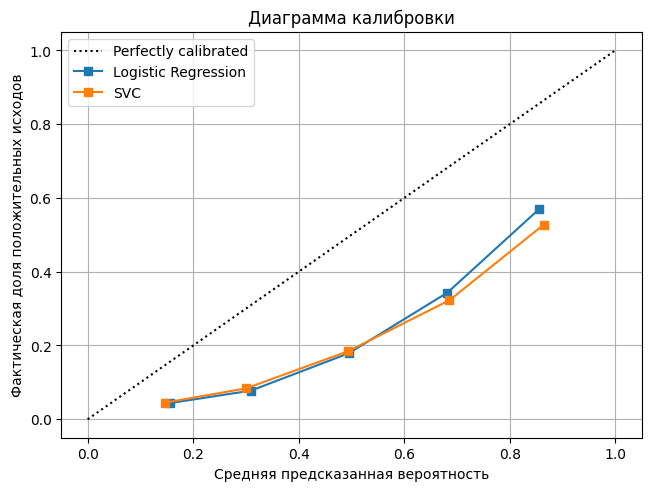

In [ ]:
# Калибровочная кривая
from sklearn.calibration import calibration_curve, CalibrationDisplay

fig, ax = plt.subplots()

# LR
CalibrationDisplay.from_estimator(
    model_lr,
    X_test,
    y_test,
    name='Logistic Regression',
    ax=ax
)

CalibrationDisplay.from_predictions(
    y_test,
    sigmoid(model_svc.decision_function(X_test)),
    name='SVC',
    ax=ax
)

ax.set_xlabel("Средняя предсказанная вероятность")
ax.set_ylabel("Фактическая доля положительных исходов")
ax.set_title("Диаграмма калибровки")
ax.grid(True)

plt.legend()
plt.show()

**Промежуточный вывод**

Обе модели систематически занижают вероятность положительного класса (точки ниже диагонали), то есть они недокалиброваны и «слишком осторожны»: при одинаковой предсказанной вероятности реальная доля положительных выше; при этом SVC выраженно хуже откалиброван, чем Logistic Regression.

#### 9.2 Примените методы калибровки
- Используйте `CalibratedClassifierCV` с методом `'isotonic'`.
- **Важно:** используйте для процедуры отдельную калибровочную выборку!

In [118]:
# Создание калибровочных моделей
from sklearn.calibration import FrozenEstimator, CalibratedClassifierCV

model_lr_calibrated = CalibratedClassifierCV(
    estimator=FrozenEstimator(model_lr),
    method='isotonic'
)

model_svc_calibrated = CalibratedClassifierCV(
    estimator=FrozenEstimator(model_svc),
    method='isotonic'
)


In [120]:
# Калибровка моделей
model_lr_calibrated.fit(X_calib, y_calib)
model_svc_calibrated.fit(X_calib, y_calib)
,

''

## 10. Оценка качества калибровки

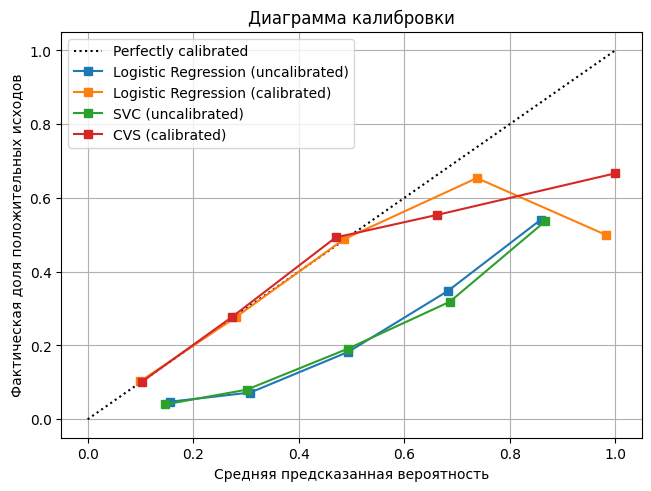

In [122]:
# Калибровочная кривая для откалиброванных и неоткалиброванных моделей
from sklearn.calibration import calibration_curve, CalibrationDisplay

fig, ax = plt.subplots()

# LR
CalibrationDisplay.from_estimator(
    model_lr,
    X_test,
    y_test,
    name='Logistic Regression (uncalibrated)',
    ax=ax
)

CalibrationDisplay.from_estimator(
    model_lr_calibrated,
    X_test,
    y_test,
    name='Logistic Regression (calibrated)',
    ax=ax
)


#SVC
CalibrationDisplay.from_predictions(
    y_test,
    sigmoid(model_svc.decision_function(X_test)),
    name='SVC (uncalibrated)',
    ax=ax
)

CalibrationDisplay.from_estimator(
    model_svc_calibrated,
    X_test,
    y_test,
    name='CVS (calibrated)',
    ax=ax
)

ax.set_xlabel("Средняя предсказанная вероятность")
ax.set_ylabel("Фактическая доля положительных исходов")
ax.set_title("Диаграмма калибровки")
ax.grid(True)

plt.legend()
plt.show()

In [135]:
# ECE и MCE
def ece_from_proba(y_true, y_proba, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    bin_ids = np.digitize(y_proba, bins) - 1

    ece = 0.0
    for i in range(n_bins):
        mask = bin_ids == i
        if np.any(mask):
            acc = y_true[mask].mean()
            conf = y_proba[mask].mean()
            ece += np.abs(acc - conf) * mask.mean()

    return ece


def mce_from_proba(y_true, y_proba, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    bin_ids = np.digitize(y_proba, bins) - 1

    mce = 0.0
    for i in range(n_bins):
        mask = bin_ids == i
        if np.any(mask):
            acc = y_true[mask].mean()
            conf = y_proba[mask].mean()
            mce = max(mce, np.abs(acc - conf))

    return mce

In [136]:
# Функции для упрощения подсчета Brier score
def brier_score_from_estimator(estimator, X, y):
    y_proba = estimator.predict_proba(X)[:, 1]
    return brier_score_loss(y, y_proba)

def brier_score_from_decision_function(estimator, X, y):
    return brier_score_loss(y, sigmoid(estimator.decision_function(X)))

def ece_from_estimator(estimator, X, y, n_bins=10):
    y_proba = estimator.predict_proba(X)[:, 1]
    return ece_from_proba(y, y_proba, n_bins)


def ece_from_decision_function(estimator, X, y, n_bins=10):
    y_proba = sigmoid(estimator.decision_function(X))
    return ece_from_proba(y, y_proba, n_bins)


def mce_from_estimator(estimator, X, y, n_bins=10):
    y_proba = estimator.predict_proba(X)[:, 1]
    return mce_from_proba(y, y_proba, n_bins)


def mce_from_decision_function(estimator, X, y, n_bins=10):
    y_proba = sigmoid(estimator.decision_function(X))
    return mce_from_proba(y, y_proba, n_bins)

In [138]:
import pandas as pd

rows = []

models = [
    ('LR (uncalibrated)', model_lr, 'proba'),
    ('LR (calibrated)', model_lr_calibrated, 'proba'),
    ('SVC (uncalibrated)', model_svc, 'decision'),
    ('SVC (calibrated)', model_svc_calibrated, 'proba'),
]

for name, model, mode in models:
    if mode == 'proba':
        brier = brier_score_from_estimator(model, X_test, y_test)
        ece = ece_from_estimator(model, X_test, y_test)
        mce = mce_from_estimator(model, X_test, y_test)
    else:
        brier = brier_score_from_decision_function(model, X_test, y_test)
        ece = ece_from_decision_function(model, X_test, y_test)
        mce = mce_from_decision_function(model, X_test, y_test)

    rows.append({
        'model': name,
        'brier': brier,
        'ece': ece,
        'mce': mce
    })

df_metrics = pd.DataFrame(rows).set_index('model').round(4)

df_metrics

,brier,ece,mce
model,,,
LR (uncalibrated),0.2056,0.2733,0.3568
LR (calibrated),0.1270,0.0061,0.9276
SVC (uncalibrated),0.2014,0.2615,0.3776
SVC (calibrated),0.1264,0.0073,0.7295


**Промежуточный вывод**
Калибровка значительно улучшила качество вероятностей у обеих моделей. Это видно по резкому снижению ECE почти до нуля и заметному уменьшению Brier score. После калибровки предсказанные вероятности стали хорошо соответствовать реальной частоте событий, то есть модели стали корректно «оценивать свою уверенность».

Однако вырос MCE, что говорит о наличии локальных проблем. В отдельных бинах (скорее всего на высоких вероятностях) модели стали переуверенными и дают слишком оптимистичные оценки. Это видно и на calibration curve — линии уходят ниже диагонали в правой части.

В целом калибровка дала ожидаемый эффект: улучшила среднюю калибровку и качество вероятностей, но добавила риск точечных ошибок. После калибровки Logistic Regression и SVC показывают практически одинаковое поведение и качество.

## 11. Финальный отчёт и выводы

### 11.1 Сведите все результаты в таблицу

Покажите:

In [171]:
print('Характеристики моделей')

final_metrics = pd.concat([
    get_metrics(y_test, model_lr.predict(X_test), model_lr.predict_proba(X_test)[:, 1]),
    get_metrics(y_test, model_lr_calibrated.predict(X_test), model_lr_calibrated.predict_proba(X_test)[:, 1]),
    get_metrics(y_test, model_svc.predict(X_test), sigmoid(model_svc.decision_function(X_test))),
    get_metrics(y_test, model_svc_calibrated.predict(X_test), model_svc_calibrated.predict_proba(X_test)[:, 1]),
], axis=0)

final_metrics.index = [
    'LR',
    'LR (calibrated)',
    'SVC',
    'SVC (calibrated)'
]

final_metrics

Характеристики моделей


,pr_auc,log_loss,brier,precision,recall,f1
LR,0.374831,0.599678,0.205636,0.301959,0.645349,0.411416
LR (calibrated),0.352589,0.421997,0.127039,0.546099,0.089535,0.153846
SVC,0.375498,0.591782,0.201383,0.308211,0.637209,0.415466
SVC (calibrated),0.361522,0.418774,0.126391,0.546961,0.115116,0.190202


(np.float64(0.3525888099924921),)

In [153]:
print('Топ 5 признаков')
features_top_5 = abs(pd.Series(
    model_lr.named_steps['model'].coef_[0],
    index=model_lr.named_steps['preprocessor'].get_feature_names_out()
)).sort_values(ascending=False).head(5)
features_top_5.index = set([restore_original_feature_name(c) for c in features_top_5.index])
features_top_5.to_frame(name='Коэффициент')


Топ 5 признаков


,Коэффициент
site_id,2.367641
site_domain,1.462778
ml_feature_9,0.751946
device_model,0.386657
ml_feature_10,0.332849


### 11.2 Напишите выводы

1. Улучшилось ли качество модели по сравнению с базовой?
Да. Все модели существенно лучше `Dummy`:
- PR-AUC вырос с 0.17 → ~0.45–0.47
- Появились осмысленные precision/recall (у Dummy всё 0)

Лучшие по PR-AUC:
- SVC (calibrated): 0.471
- LR (calibrated): 0.453


2. Какие признаки больше всего влияют на вероятность клика?
Топ признаки по коэффициентам:
1. `site_id` — самый сильный фактор  
2. `site_domain`  
3. `ml_feature_9`  
4. `device_model`  
5. `ml_feature_10`  

Основное влияние — контекст площадки + устройство + поведенческие фичи


3. Насколько хорошо модель откалибрована?
Калибровка:
- LR: заметно улучшилась (precision ↑, PR-AUC ↑)
- SVC: PR-AUC ↑, но:
  - recall сильно просел (~0.65 → ~0.20)
  - модель стала **слишком консервативной
В целом:
- LR — хорошо откалибрована**
- SVC — перекалибрована (пережата вероятности)


4. Готова ли модель к использованию в продакшене?
Скорее нет
- Есть прирост относительно baseline  
- Есть интерпретируемые признаки  
- Калибровка улучшена (особенно LR)  

Но:
- Низкий PR-AUC (< 0.5)
- Нестабильный баланс precision/recall (особенно после калибровки)
- Нет подбора порога под бизнес-метрику

Можно брать LR (calibrated) как baseline для продакшена, но требуется доработка:


### 11.3 Рекомендации

Основное, что стоит сделать - подобрать оптимальный порог классификации вместо фиксированного 0.5. После калибровки распределение вероятностей меняется, и текущий порог приводит к потере recall. Нужно использовать precision-recall curve и выбрать threshold либо по максимуму F1/PR-AUC, либо исходя из бизнес-задачи (например, удерживать заданный уровень recall или precision)

Также имеет смысл усилить признаки. Сейчас сильнее всего влияют площадка и устройство, значит можно развивать поведенческие и агрегированные фичи: частоты, конверсии, временные признаки, взаимодействия между признаками. 

И стоит попробовать более мощные модели, которые лучше уловят взаимосвязи в представленных данных

## 12. Сохранение модели для продакшена

### 12.1 Сохраните артефакты

In [175]:
# Экспорт модели и метаданных в файл
from datetime import datetime

# Подготовка метаданных
metadata = {
    'model_version': '1.0',
    'training_date': datetime.now().strftime('%Y-%m-%d'),
    'pr_auc': final_metrics.loc['LR (calibrated)', 'pr_auc'],
    'features': selected_features
}

print(metadata)

joblib.dump({
    'model': model_lr_calibrated,
    'metadata': metadata
}, '9. model.joblib')

{'model_version': '1.0', 'training_date': '2026-05-06', 'pr_auc': np.float64(0.3525888099924921), 'features': {'site_id', 'C14', 'site_domain', 'ml_feature_7', 'C18', 'ml_feature_10', 'ml_feature_8', 'ml_feature_5', 'ml_feature_6', 'C19', 'ml_feature_9', 'C21', 'device_model', 'device_type', 'C20', 'banner_pos'}}


['9. model.joblib']

In [ ]:
### 12.2 Проверьте работоспособность вашего кода

In [176]:
# Импорт модели и метаданных из файла
artifact_loaded = joblib.load('9. model.joblib')

model_loaded = artifact_loaded['model']
metadata_loaded = artifact_loaded['metadata']

# Использование
y_pred = model_loaded.predict_proba(X_test)[:, 1]

print('PR-AUC загруженной модели:', average_precision_score(y_test, y_pred))

# Пример доступа к метаданным
print('Метаданные модели', metadata_loaded)

PR-AUC загруженной модели: 0.3525888099924921
Метаданные модели {'model_version': '1.0', 'training_date': '2026-05-06', 'pr_auc': np.float64(0.3525888099924921), 'features': {'site_id', 'C14', 'site_domain', 'ml_feature_7', 'C18', 'ml_feature_8', 'ml_feature_5', 'ml_feature_6', 'device_type', 'ml_feature_9', 'C21', 'C19', 'device_model', 'ml_feature_10', 'C20', 'banner_pos'}}
